# Apartado 1. Estudiar la distribución de la temperatura, la irradiación y la precipitación en las celdas 01 y 10.

## Importación y carga de datos

En esta sección se importan los datos y librerías necesarias para el análisis del Apartado 1.

In [1]:
from carga_de_datos import *
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
IMAGES_DIR = PROJECT_ROOT / 'images'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


Tamaño de df_orig_temp con los datos cargados: (4383, 15)
Dataframe con todos los datos leidos (filas: días, columnas: variables):
           FECHA  TEMP_CELDA01  TEMP_CELDA02  TEMP_CELDA03  TEMP_CELDA04  \
0     2014-01-01      9.304810      9.234131      9.134725      8.917480   
1     2014-01-02     11.986209     11.888858     11.768883     11.706729   
2     2014-01-03     13.474006     13.405910     13.308051     13.187058   
3     2014-01-04     11.460185     11.400940     11.306010     11.271545   
4     2014-01-05      7.990672      8.004791      7.974009      7.590749   
...          ...           ...           ...           ...           ...   
4378  2025-12-27      6.853189      6.883666      6.892943      6.586832   
4379  2025-12-28      8.640758      8.662160      8.675710      8.074249   
4380  2025-12-29      7.409761      7.522859      7.593782      6.951753   
4381  2025-12-30      8.605798      8.644759      8.652287      7.629785   
4382  2025-12-31      7.655819   

## 1.1. ¿Cómo es la distribución de la temperatura en la celda 01? ¿Y cómo es la distribución de la irradiación y la de la precipitación en la celda 01? ¿Cómo se distribuye cada una de estas tres variables en la celda 10?

### Exploración inicial de las tres variables en la celda 01

Se muestra una visión general temporal de temperatura, irradiación y precipitación para contextualizar las distribuciones.

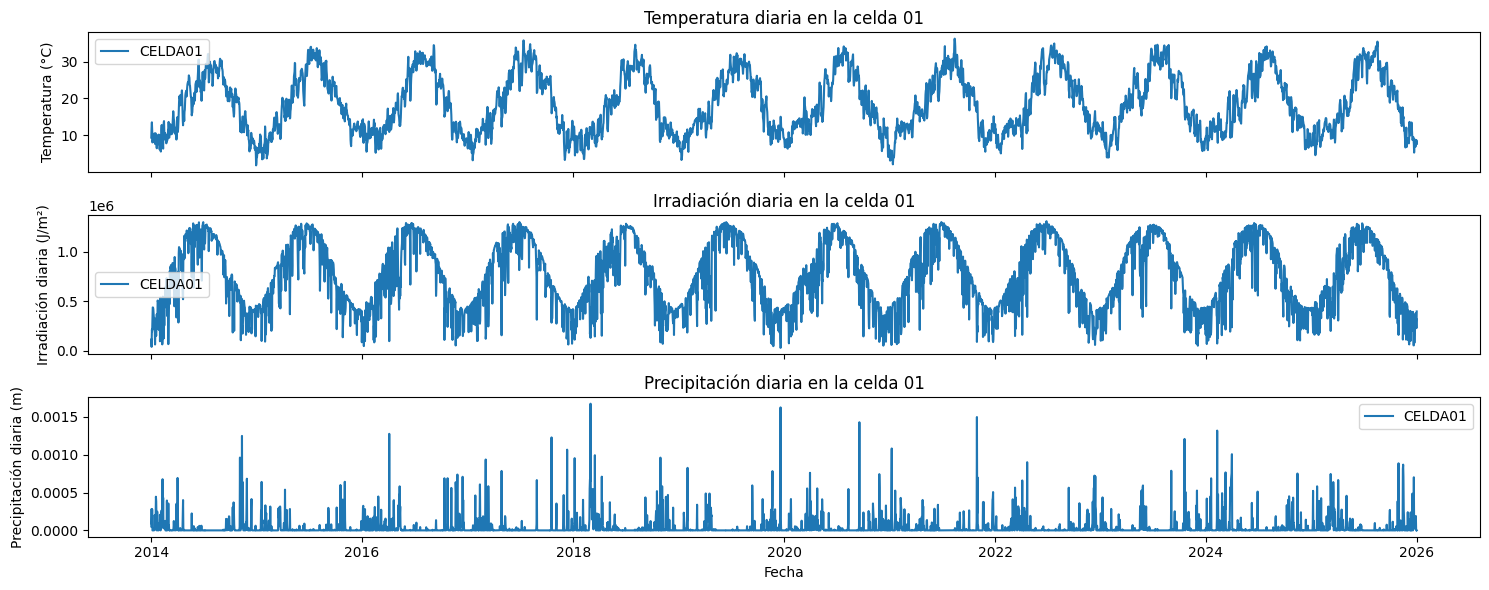

In [2]:
# VISUALIZACION DE TEMPERATURA A LO LARGO DEL TIEMPO
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(15, 6),
    sharex=True
)

# Temperatura
axes[0].plot(df_orig_temp.FECHA, df_orig_temp.TEMP_CELDA01, label='CELDA01')
axes[0].set_title('Temperatura diaria en la celda 01')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].legend()

# Irradiacion
axes[1].plot(df_orig_irrad.FECHA, df_orig_irrad.IRRAD_CELDA01, label='CELDA01')
axes[1].set_title('Irradiación diaria en la celda 01')
axes[1].set_ylabel('Irradiación diaria (J/m²)')
axes[1].legend()

# Precipitacion
axes[2].plot(df_orig_precip.FECHA, df_orig_precip.PRECIP_CELDA01, label='CELDA01')
axes[2].set_title('Precipitación diaria en la celda 01')
axes[2].set_ylabel('Precipitación diaria (m)')
axes[2].set_xlabel('Fecha')
axes[2].legend()

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 1.1： Evolución temporal en la celda 01.png', dpi=300, bbox_inches='tight')
plt.show()

### Temperatura celda 01

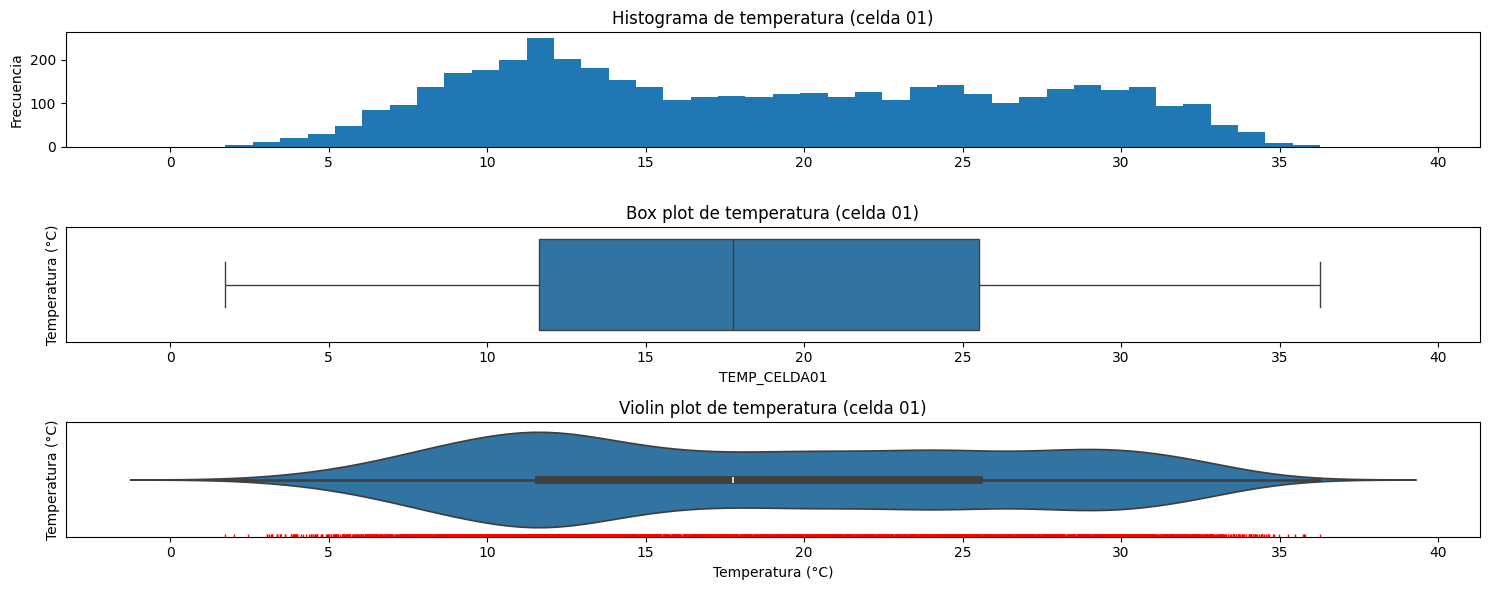

count    4383.000000
mean       18.622823
std         8.060663
min         1.746073
25%        11.641418
50%        17.765420
75%        25.510055
max        36.278950
Name: TEMP_CELDA01, dtype: float64

La distribución de la temperatura presenta una dispersión moderada, con valores aproximadamente entre 3°C y 36°C. La mediana se sitúa aproximadamente en torno a 18°C, indicando que la mayor parte de los valores se concentran en torno a temperaturas templadas.

La distribución tiene una moda alrededor de 12°C, y tiene asimetría positiva. Esto es coherente con la mezcla de valores correspondientes a distintas estaciones del año (periodos fríos y cálidos). No se observan valores atípicos extremadamente alejados del resto de observaciones.


In [3]:
# GRAFICOS TIPICOS: histograma, box plot y violin plot
nbins = 40  # numero de intervalos histograma, ajustar para buena visualizacion

# Tres ejes en vertical para sincronizar la variable x
fig = plt.figure(1, figsize=(15, 6))

# Histograma
ax1 = plt.subplot(3, 1, 1)
plt.hist(df_orig_temp.TEMP_CELDA01, bins=nbins)
ax1.set_title('Histograma de temperatura (celda 01)')
ax1.set_ylabel('Frecuencia')

# Cajas
ax2 = plt.subplot(3, 1, 2, sharex=ax1)
sns.boxplot(data=df_orig_temp.TEMP_CELDA01, orient='y')
ax2.set_title('Box plot de temperatura (celda 01)')
ax2.set_ylabel('Temperatura (°C)')
ax2.set_yticks([])

# Violin
ax3 = plt.subplot(3, 1, 3, sharex=ax1)
sns.violinplot(data=df_orig_temp.TEMP_CELDA01, orient='y')
sns.rugplot(data=df_orig_temp.TEMP_CELDA01, color='r')
ax3.set_title('Violin plot de temperatura (celda 01)')
ax3.set_ylabel('Temperatura (°C)')
ax3.set_xlabel('Temperatura (°C)')
ax3.set_yticks([])

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 1.2： Distribución de la temperatura en la celda 01.png', dpi=300, bbox_inches='tight')
plt.show()

# MEDIDAS IMPORTANTES: media, mediana...
print(df_orig_temp.TEMP_CELDA01.describe())

print("""
La distribución de la temperatura presenta una dispersión moderada, con valores aproximadamente entre 3°C y 36°C. La mediana se sitúa aproximadamente en torno a 18°C, indicando que la mayor parte de los valores se concentran en torno a temperaturas templadas.

La distribución tiene una moda alrededor de 12°C, y tiene asimetría positiva. Esto es coherente con la mezcla de valores correspondientes a distintas estaciones del año (periodos fríos y cálidos). No se observan valores atípicos extremadamente alejados del resto de observaciones.""")


### Irradiación y precipitación celda 01

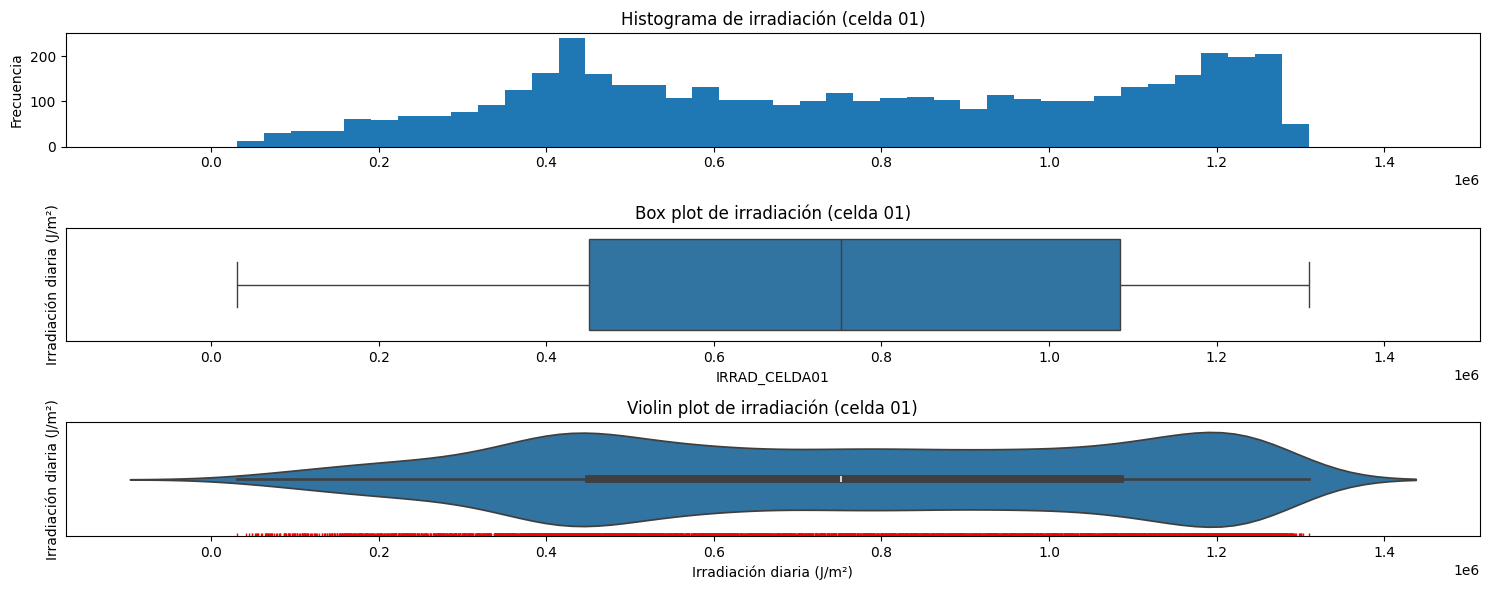

count    4.383000e+03
mean     7.556252e+05
std      3.421336e+05
min      3.119716e+04
25%      4.514383e+05
50%      7.512326e+05
75%      1.084807e+06
max      1.309572e+06
Name: IRRAD_CELDA01, dtype: float64

La irradiación es claramente bimodal, lo cual encaja con la gran diferencia entre día y noche, y los días nublados o soleados.

La dispersión es elevada, lo cual es esperable en una variable que depende fuertemente del ciclo estacional y de la cantidad de nubes diaria.


In [4]:
# GRAFICOS TIPICOS: histograma, box plot y violin plot
nbins = 40  # numero de intervalos histograma, ajustar para buena visualizacion

# Tres ejes en vertical para sincronizar la variable x
fig = plt.figure(1, figsize=(15, 6))

# Histograma
ax1 = plt.subplot(3, 1, 1)
plt.hist(df_orig_irrad.IRRAD_CELDA01, bins=nbins)
ax1.set_title('Histograma de irradiación (celda 01)')
ax1.set_ylabel('Frecuencia')

# Cajas
ax2 = plt.subplot(3, 1, 2, sharex=ax1)
sns.boxplot(data=df_orig_irrad.IRRAD_CELDA01, orient='y')
ax2.set_title('Box plot de irradiación (celda 01)')
ax2.set_ylabel('Irradiación diaria (J/m²)')
ax2.set_yticks([])

# Violin
ax3 = plt.subplot(3, 1, 3, sharex=ax1)
sns.violinplot(data=df_orig_irrad.IRRAD_CELDA01, orient='y')
sns.rugplot(data=df_orig_irrad.IRRAD_CELDA01, color='r')
ax3.set_title('Violin plot de irradiación (celda 01)')
ax3.set_ylabel('Irradiación diaria (J/m²)')
ax3.set_xlabel('Irradiación diaria (J/m²)')
ax3.set_yticks([])

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 1.3： Distribución de la irradiación en la celda 01.png', dpi=300, bbox_inches='tight')
plt.show()

# MEDIDAS IMPORTANTES: media, mediana...
print(df_orig_irrad.IRRAD_CELDA01.describe())

print("""
La irradiación es claramente bimodal, lo cual encaja con la gran diferencia entre día y noche, y los días nublados o soleados.

La dispersión es elevada, lo cual es esperable en una variable que depende fuertemente del ciclo estacional y de la cantidad de nubes diaria.""")


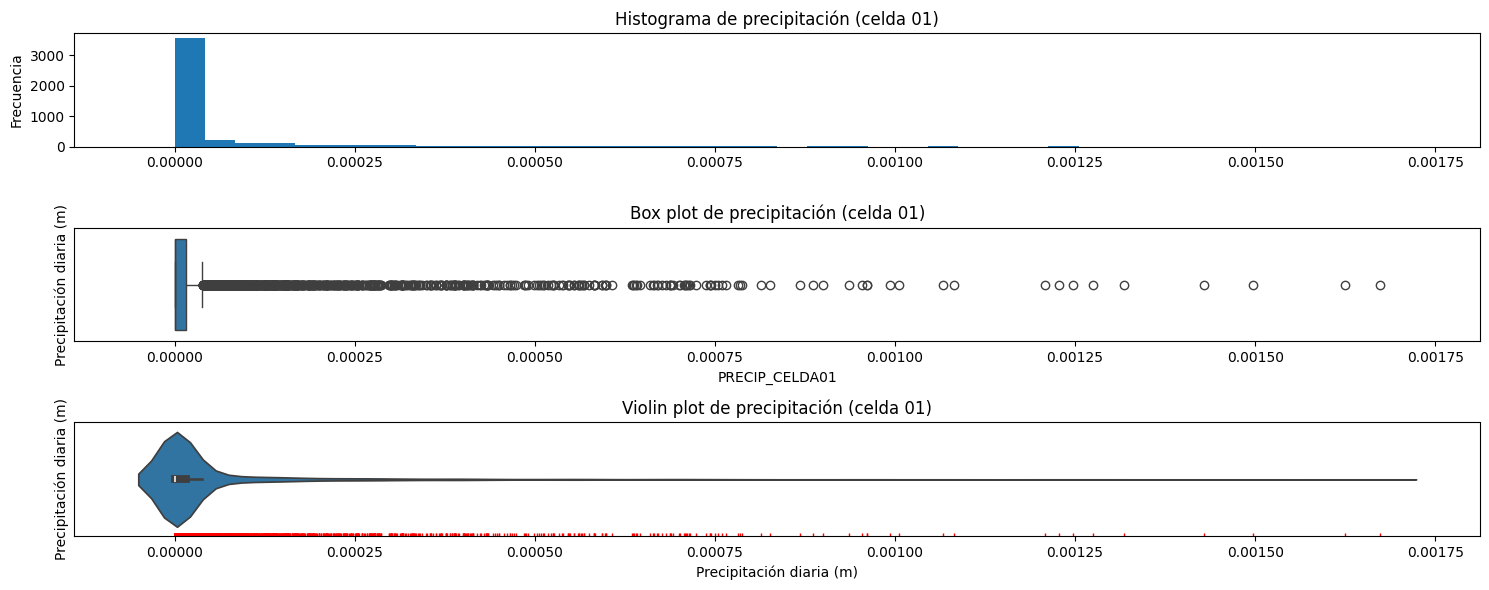

count    4.383000e+03
mean     4.639588e-05
std      1.346077e-04
min      0.000000e+00
25%      3.551443e-08
50%      9.032779e-08
75%      1.550523e-05
max      1.673124e-03
Name: PRECIP_CELDA01, dtype: float64

La precipitación muestra una gran concentración de valores cerca del 0, ya que en España la gran mayoría de días no hay lluvia.

Esto hace que tenga una gran cantidad de datos atípicos (que se pueden ver en el box plot), que hacen que la distribución sea altamente asimétrica hacia la derecha.


In [5]:
# GRAFICOS TIPICOS: histograma, box plot y violin plot
nbins = 40  # numero de intervalos histograma, ajustar para buena visualizacion

# Tres ejes en vertical para sincronizar la variable x
fig = plt.figure(1, figsize=(15, 6))

# Histograma
ax1 = plt.subplot(3, 1, 1)
plt.hist(df_orig_precip.PRECIP_CELDA01, bins=nbins)
ax1.set_title('Histograma de precipitación (celda 01)')
ax1.set_ylabel('Frecuencia')

# Cajas
ax2 = plt.subplot(3, 1, 2, sharex=ax1)
sns.boxplot(data=df_orig_precip.PRECIP_CELDA01, orient='y')
ax2.set_title('Box plot de precipitación (celda 01)')
ax2.set_ylabel('Precipitación diaria (m)')
ax2.set_yticks([])

# Violin
ax3 = plt.subplot(3, 1, 3, sharex=ax1)
sns.violinplot(data=df_orig_precip.PRECIP_CELDA01, orient='y')
sns.rugplot(data=df_orig_precip.PRECIP_CELDA01, color='r')
ax3.set_title('Violin plot de precipitación (celda 01)')
ax3.set_ylabel('Precipitación diaria (m)')
ax3.set_xlabel('Precipitación diaria (m)')
ax3.set_yticks([])

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 1.4： Distribución de la precipitación en la celda 01.png', dpi=300, bbox_inches='tight')
plt.show()

# MEDIDAS IMPORTANTES: media, mediana...
print(df_orig_precip.PRECIP_CELDA01.describe())

print("""
La precipitación muestra una gran concentración de valores cerca del 0, ya que en España la gran mayoría de días no hay lluvia.

Esto hace que tenga una gran cantidad de datos atípicos (que se pueden ver en el box plot), que hacen que la distribución sea altamente asimétrica hacia la derecha.""")


### Distribución de las variables en la celda 10

#### Temperatura

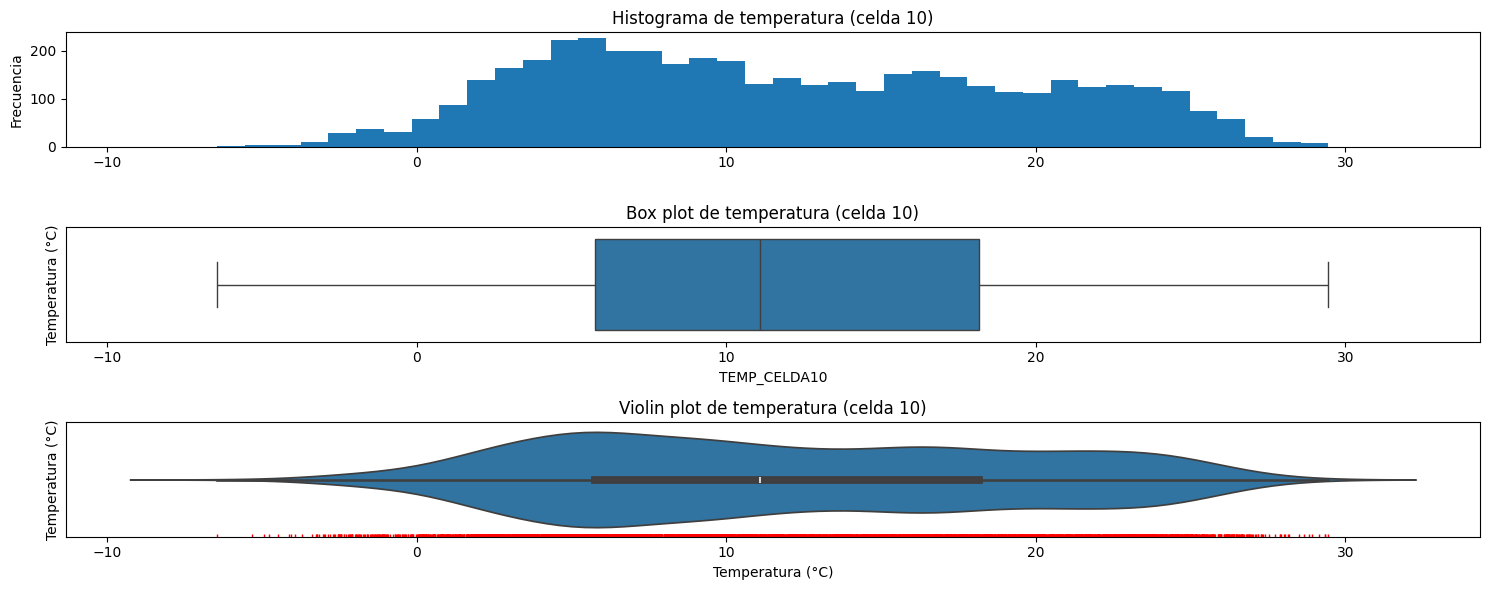

count    4383.000000
mean       12.048422
std         7.538578
min        -6.440763
25%         5.757884
50%        11.082733
75%        18.174682
max        29.457224
Name: TEMP_CELDA10, dtype: float64

La distribución de la temperatura presenta una dispersión más alta que en la celda 01, con valores aproximadamente entre -5°C y 30°C. La mediana se sitúa aproximadamente en torno a 11°C, indicando que la mayor parte de los valores se concentran en torno a temperaturas frías.

La distribución tiene una moda alrededor de 5°C, y tiene asimetría positiva. Esto es coherente con la mezcla de valores correspondientes a distintas estaciones del año (periodos fríos y cálidos), aunque en un sitio seguramente más al Norte de España.


In [6]:
# GRAFICOS TIPICOS: histograma, box plot y violin plot
nbins = 40  # numero de intervalos histograma, ajustar para buena visualizacion

# Tres ejes en vertical para sincronizar la variable x
fig = plt.figure(1, figsize=(15, 6))

# Histograma
ax1 = plt.subplot(3, 1, 1)
plt.hist(df_orig_temp.TEMP_CELDA10, bins=nbins)
ax1.set_title('Histograma de temperatura (celda 10)')
ax1.set_ylabel('Frecuencia')

# Cajas
ax2 = plt.subplot(3, 1, 2, sharex=ax1)
sns.boxplot(data=df_orig_temp.TEMP_CELDA10, orient='y')
ax2.set_title('Box plot de temperatura (celda 10)')
ax2.set_ylabel('Temperatura (°C)')
ax2.set_yticks([])

# Violin
ax3 = plt.subplot(3, 1, 3, sharex=ax1)
sns.violinplot(data=df_orig_temp.TEMP_CELDA10, orient='y')
sns.rugplot(data=df_orig_temp.TEMP_CELDA10, color='r')
ax3.set_title('Violin plot de temperatura (celda 10)')
ax3.set_ylabel('Temperatura (°C)')
ax3.set_xlabel('Temperatura (°C)')
ax3.set_yticks([])

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 1.5： Distribución de la temperatura en la celda 10.png', dpi=300, bbox_inches='tight')
plt.show()

# MEDIDAS IMPORTANTES: media, mediana...
print(df_orig_temp.TEMP_CELDA10.describe())

print("""
La distribución de la temperatura presenta una dispersión más alta que en la celda 01, con valores aproximadamente entre -5°C y 30°C. La mediana se sitúa aproximadamente en torno a 11°C, indicando que la mayor parte de los valores se concentran en torno a temperaturas frías.

La distribución tiene una moda alrededor de 5°C, y tiene asimetría positiva. Esto es coherente con la mezcla de valores correspondientes a distintas estaciones del año (periodos fríos y cálidos), aunque en un sitio seguramente más al Norte de España.""")


### Irradiación

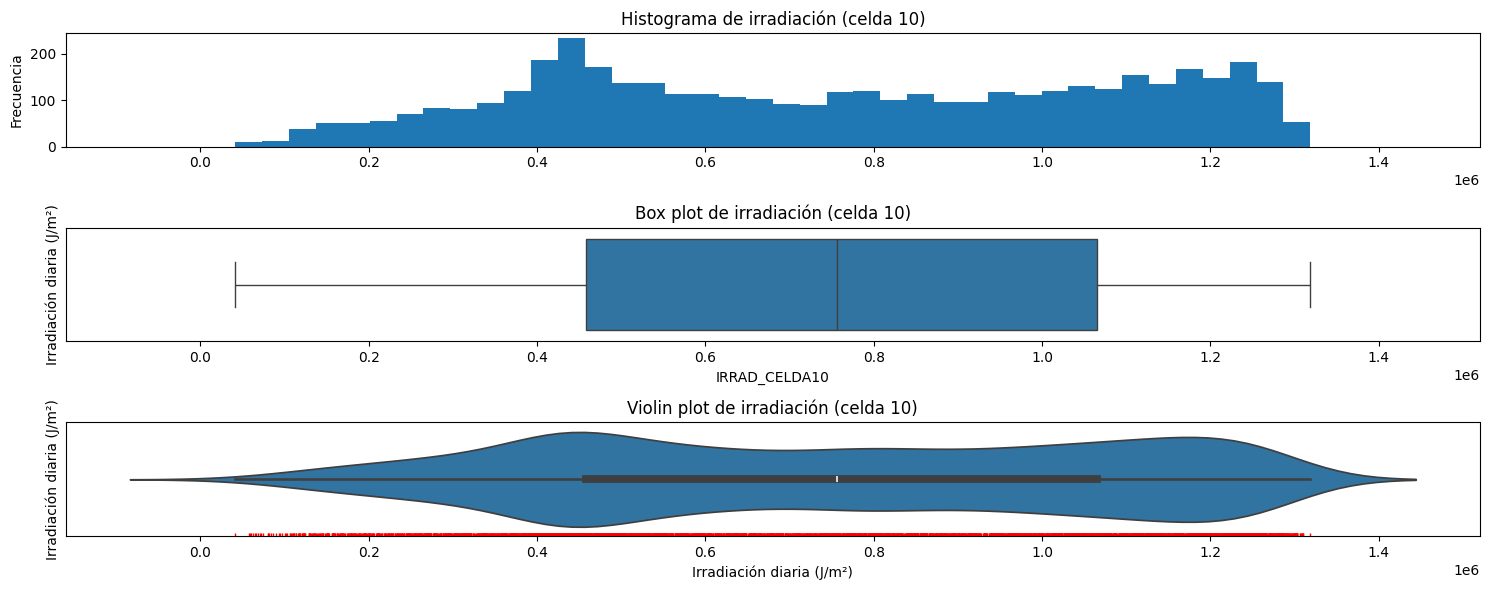

count    4.383000e+03
mean     7.550320e+05
std      3.348174e+05
min      4.136404e+04
25%      4.576424e+05
50%      7.565648e+05
75%      1.065729e+06
max      1.318834e+06
Name: IRRAD_CELDA10, dtype: float64

La irradiación es claramente bimodal, lo cual encaja con la gran diferencia entre día y noche, y los días nublados o soleados.

La dispersión es elevada, lo cual es esperable en una variable que depende fuertemente del ciclo estacional y de la cantidad de nubes diaria. Es casi idéntica a la celda 01.


In [7]:
# GRAFICOS TIPICOS: histograma, box plot y violin plot
nbins = 40  # numero de intervalos histograma, ajustar para buena visualizacion

# Tres ejes en vertical para sincronizar la variable x
fig = plt.figure(1, figsize=(15, 6))

# Histograma
ax1 = plt.subplot(3, 1, 1)
plt.hist(df_orig_irrad.IRRAD_CELDA10, bins=nbins)
ax1.set_title('Histograma de irradiación (celda 10)')
ax1.set_ylabel('Frecuencia')

# Cajas
ax2 = plt.subplot(3, 1, 2, sharex=ax1)
sns.boxplot(data=df_orig_irrad.IRRAD_CELDA10, orient='y')
ax2.set_title('Box plot de irradiación (celda 10)')
ax2.set_ylabel('Irradiación diaria (J/m²)')
ax2.set_yticks([])

# Violin
ax3 = plt.subplot(3, 1, 3, sharex=ax1)
sns.violinplot(data=df_orig_irrad.IRRAD_CELDA10, orient='y')
sns.rugplot(data=df_orig_irrad.IRRAD_CELDA10, color='r')
ax3.set_title('Violin plot de irradiación (celda 10)')
ax3.set_ylabel('Irradiación diaria (J/m²)')
ax3.set_xlabel('Irradiación diaria (J/m²)')
ax3.set_yticks([])

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 1.6： Distribución de la irradiación en la celda 10.png', dpi=300, bbox_inches='tight')
plt.show()

# MEDIDAS IMPORTANTES: media, mediana...
print(df_orig_irrad.IRRAD_CELDA10.describe())

print("""
La irradiación es claramente bimodal, lo cual encaja con la gran diferencia entre día y noche, y los días nublados o soleados.

La dispersión es elevada, lo cual es esperable en una variable que depende fuertemente del ciclo estacional y de la cantidad de nubes diaria. Es casi idéntica a la celda 01.""")


### Precipitación

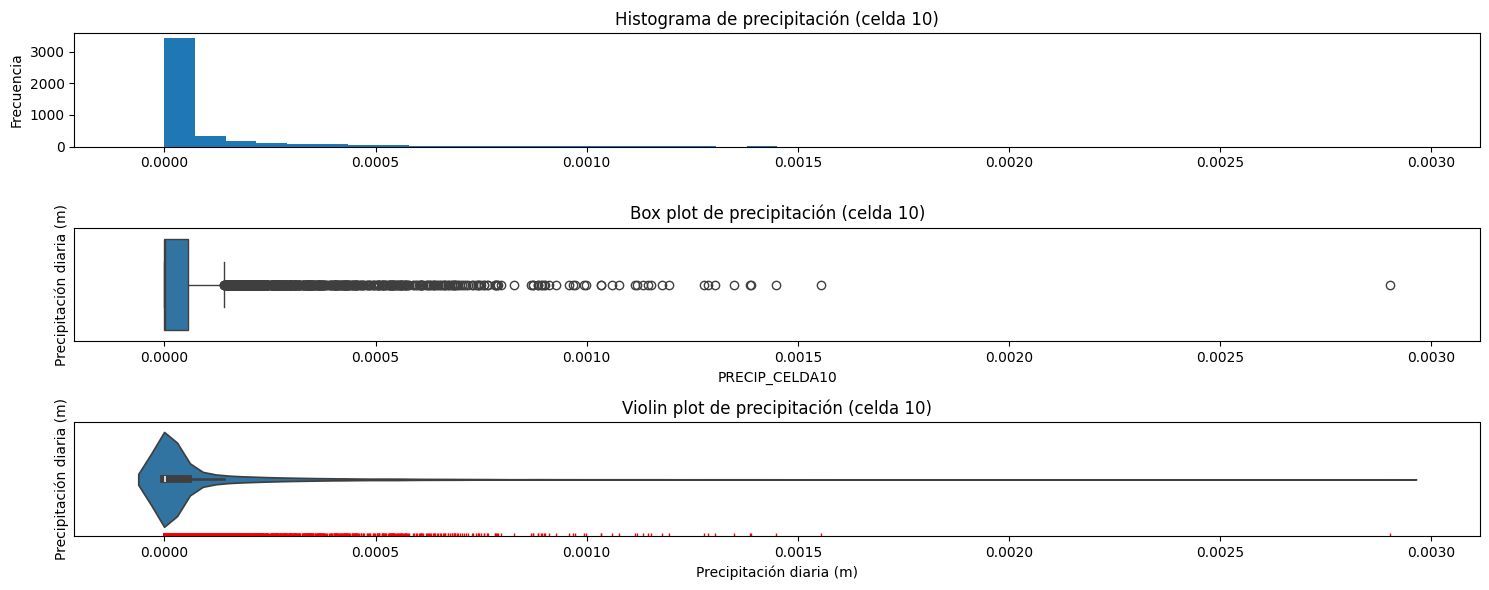

count    4.383000e+03
mean     7.018278e-05
std      1.650461e-04
min      0.000000e+00
25%      5.238656e-08
50%      1.556830e-06
75%      5.653638e-05
max      2.902339e-03
Name: PRECIP_CELDA10, dtype: float64

La precipitación muestra una gran concentración de valores cerca del 0, ya que en España la gran mayoría de días no hay lluvia.

Esto hace que tenga una gran cantidad de datos atípicos (que se pueden ver en el box plot), que hacen que la distribución sea altamente asimétrica hacia la derecha.

Podemos ver que el percentil 75% se sitúa alrededor de 5.65, considerablemente más alto que el 1.5 de la celda 01, y que además hay un outlier mucho más alejado del 0. Esto encaja con la idea de que es un lugar más al Norte.


In [8]:
# GRAFICOS TIPICOS: histograma, box plot y violin plot
nbins = 40  # numero de intervalos histograma, ajustar para buena visualizacion

# Tres ejes en vertical para sincronizar la variable x
fig = plt.figure(1, figsize=(15, 6))

# Histograma
ax1 = plt.subplot(3, 1, 1)
plt.hist(df_orig_precip.PRECIP_CELDA10, bins=nbins)
ax1.set_title('Histograma de precipitación (celda 10)')
ax1.set_ylabel('Frecuencia')

# Cajas
ax2 = plt.subplot(3, 1, 2, sharex=ax1)
sns.boxplot(data=df_orig_precip.PRECIP_CELDA10, orient='y')
ax2.set_title('Box plot de precipitación (celda 10)')
ax2.set_ylabel('Precipitación diaria (m)')
ax2.set_yticks([])

# Violin
ax3 = plt.subplot(3, 1, 3, sharex=ax1)
sns.violinplot(data=df_orig_precip.PRECIP_CELDA10, orient='y')
sns.rugplot(data=df_orig_precip.PRECIP_CELDA10, color='r')
ax3.set_title('Violin plot de precipitación (celda 10)')
ax3.set_ylabel('Precipitación diaria (m)')
ax3.set_xlabel('Precipitación diaria (m)')
ax3.set_yticks([])

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 1.7： Distribución de precipitación en la celda 10.png', dpi=300, bbox_inches='tight')
plt.show()

# MEDIDAS IMPORTANTES: media, mediana...
print(df_orig_precip.PRECIP_CELDA10.describe())

print("""
La precipitación muestra una gran concentración de valores cerca del 0, ya que en España la gran mayoría de días no hay lluvia.

Esto hace que tenga una gran cantidad de datos atípicos (que se pueden ver en el box plot), que hacen que la distribución sea altamente asimétrica hacia la derecha.

Podemos ver que el percentil 75% se sitúa alrededor de 5.65, considerablemente más alto que el 1.5 de la celda 01, y que además hay un outlier mucho más alejado del 0. Esto encaja con la idea de que es un lugar más al Norte.""")


## 1.2. ¿La distribución de la temperatura en las celdas indicadas cambia con el día de la semana? ¿Y con el mes? ¿Y con el año? ¿Y la irradiación y la precipitación cambian según el día de la semana, el mes y el año? ¿Dónde aparecen los atípicos más llamativos?

### Temperatura para las celdas 01 y 10

In [9]:
def preparar_datos(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepara el dataframe para el análisis haciendo que la columna 'Fecha' tenga
    el formato adecuado y extrayendo el año, mes y día.

    Args:
        df: El dataframe con los datos.

    Returns:
        pd.DataFrame: Nuevo dataframe con las columnas añadidas: 'ANNO', 'MES', 'DIA'.
    """
    
    temp_fechas = pd.to_datetime(df['FECHA'])

    df['ANNO'] = temp_fechas.dt.year
    df['MES'] = temp_fechas.dt.month
    df['DIA'] = temp_fechas.dt.day_name()

    return df


df_orig_temp = preparar_datos(df_orig_temp)
df_orig_irrad = preparar_datos(df_orig_irrad)
df_orig_precip = preparar_datos(df_orig_precip)

C:\Users\anton\AppData\Local\Temp\ipykernel_19716\3328860016.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels([MESES[i] for i in range(1, 13)])
C:\Users\anton\AppData\Local\Temp\ipykernel_19716\3328860016.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels([MESES[i] for i in range(1, 13)])


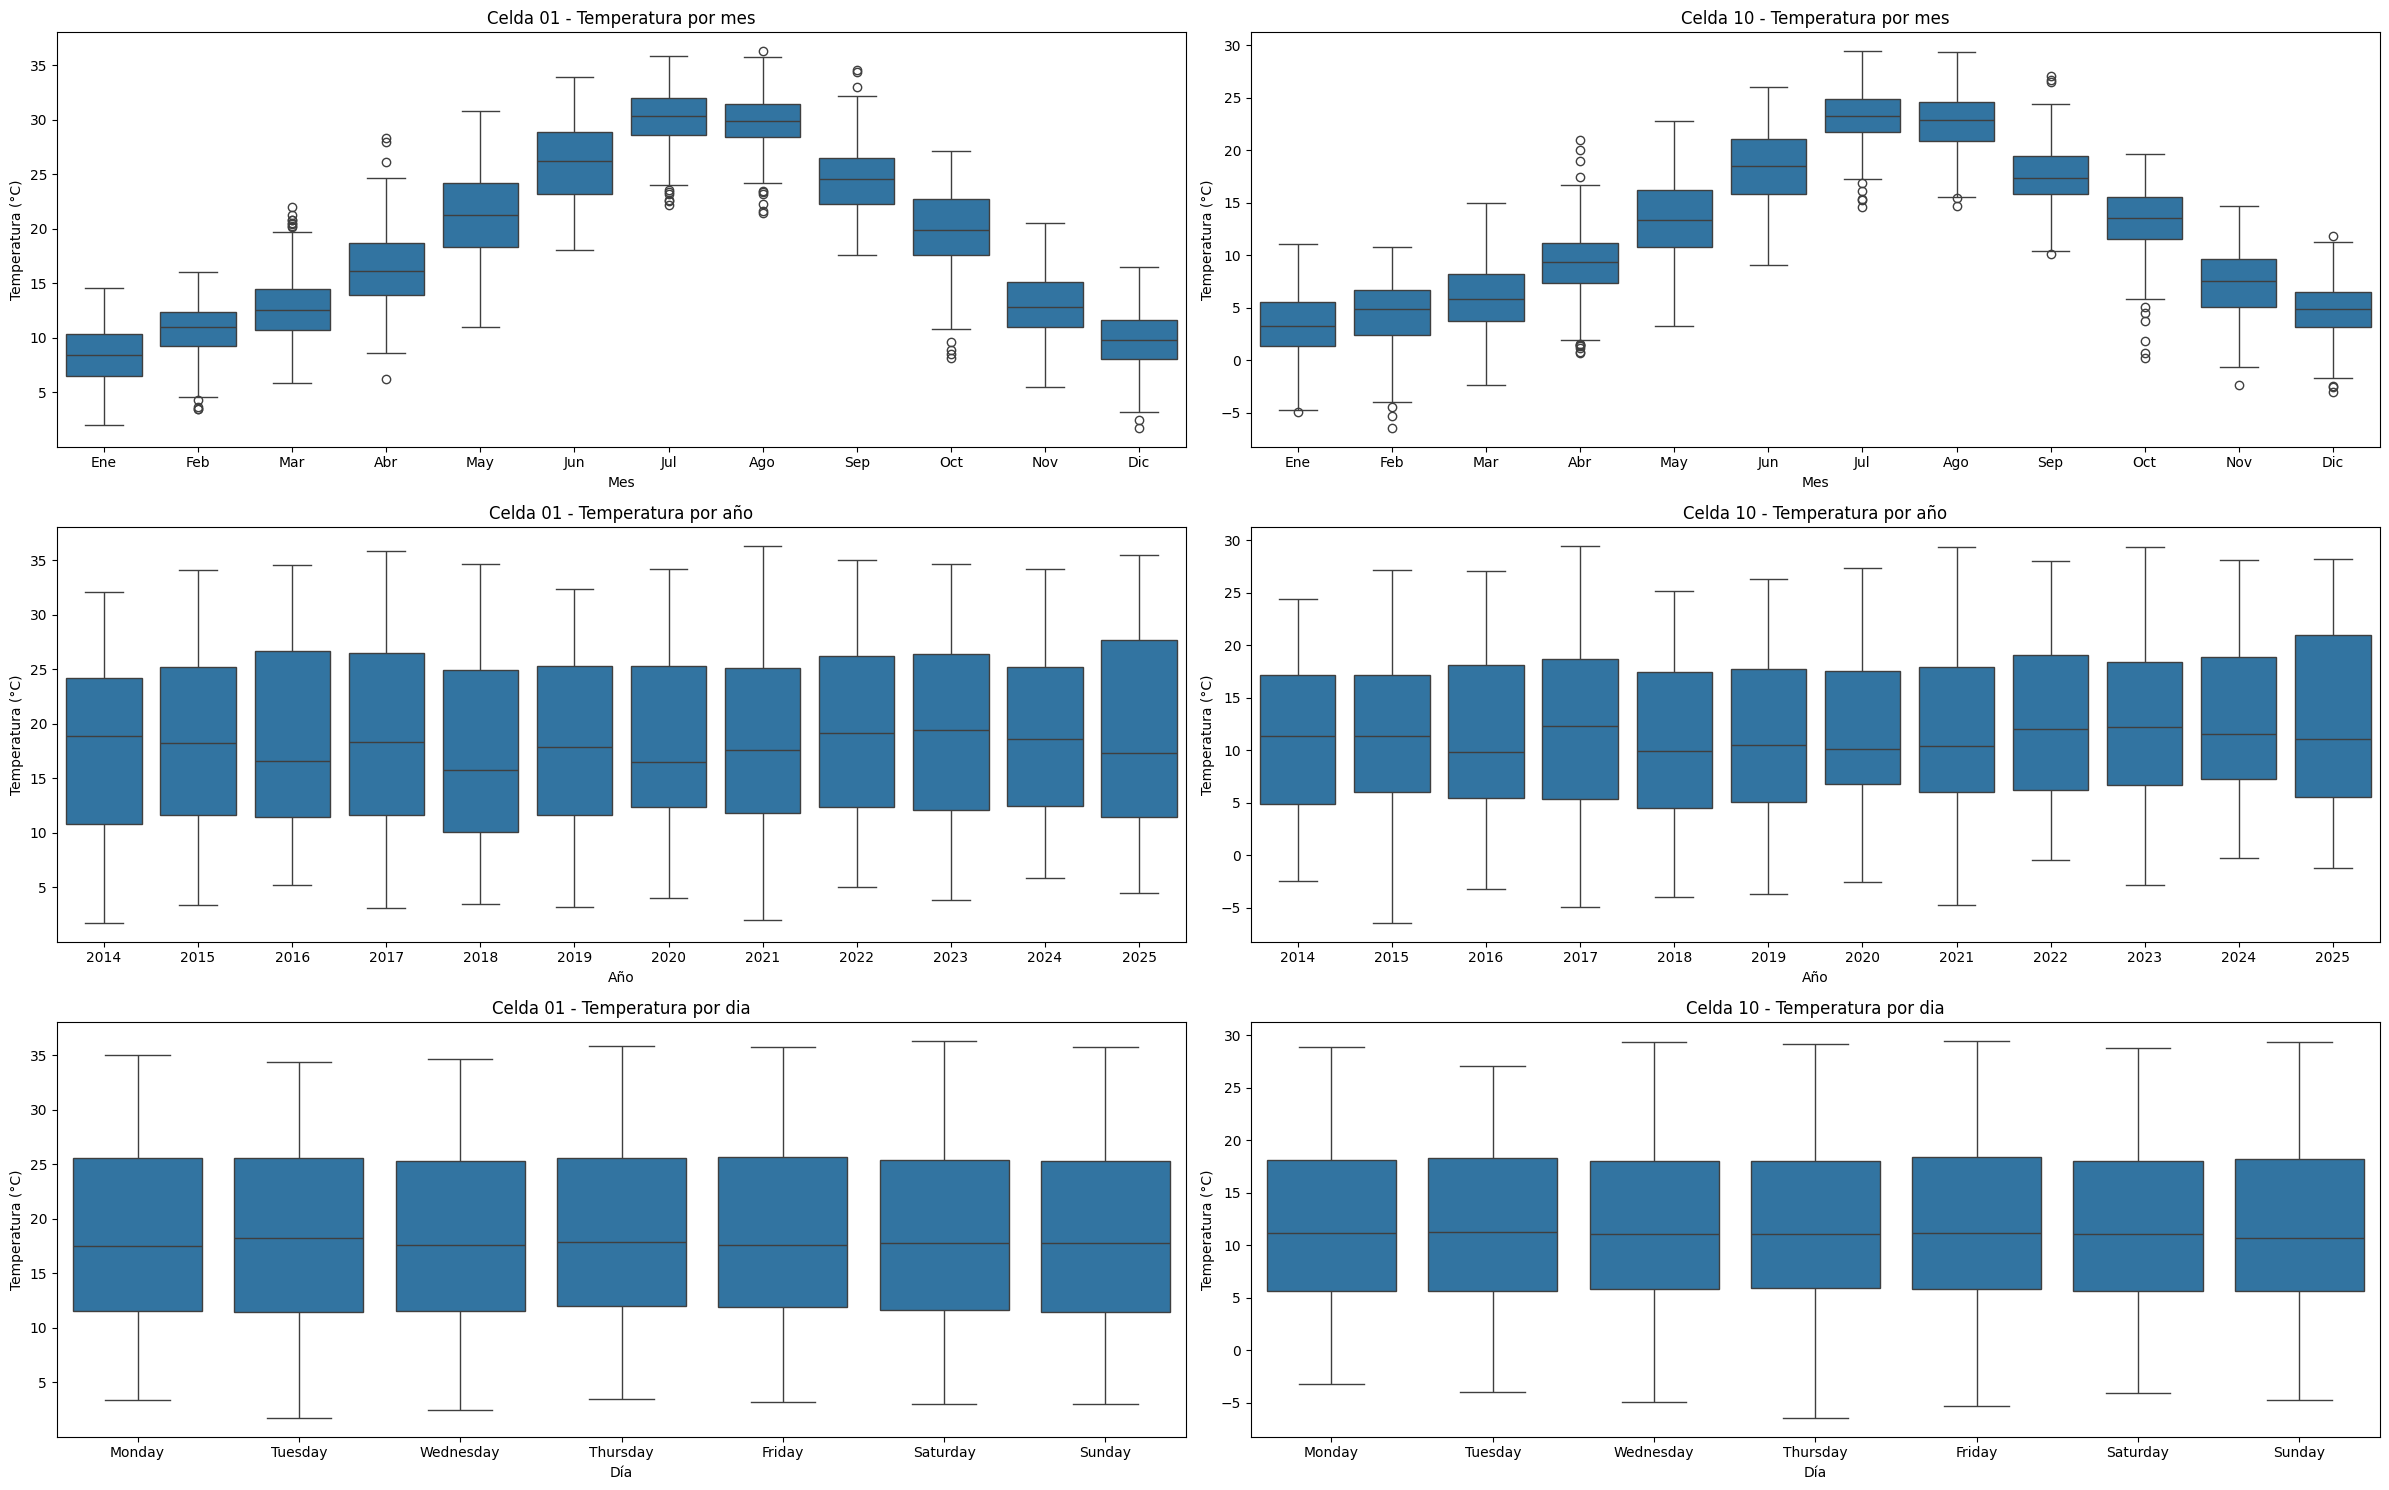


Podemos ver que la temperatura cambia significativamente con el mes (lógicamente), y que no cambia nada con el día de la semana.
También vemos que con el año cambia ligeramente, aunque se mantiene relativamente estable.


In [10]:
MESES = {1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun',
         7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(24, 15))

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# COLUMNA DE LA IZQUIERDA: CELDA 01

# 1. Distribucion por mes
sns.boxplot(x='MES', y='TEMP_CELDA01', data=df_orig_temp, ax=axes[0, 0])
axes[0, 0].set_title('Celda 01 - Temperatura por mes')
axes[0, 0].set_xlabel('Mes')
axes[0, 0].set_ylabel('Temperatura (°C)')
axes[0, 0].set_xticklabels([MESES[i] for i in range(1, 13)])

# 2. Distribucion por año
sns.boxplot(x='ANNO', y='TEMP_CELDA01', data=df_orig_temp, ax=axes[1, 0])
axes[1, 0].set_title('Celda 01 - Temperatura por año')
axes[1, 0].set_xlabel('Año')
axes[1, 0].set_ylabel('Temperatura (°C)')

# 3. Distribucion por dia de la semana
sns.boxplot(x='DIA', y='TEMP_CELDA01', data=df_orig_temp, order=days_order, ax=axes[2, 0])
axes[2, 0].set_title('Celda 01 - Temperatura por dia')
axes[2, 0].set_xlabel('Día')
axes[2, 0].set_ylabel('Temperatura (°C)')

# COLUMNA DE LA DERECHA: CELDA 10

# 1. Distribucion por mes
sns.boxplot(x='MES', y='TEMP_CELDA10', data=df_orig_temp, ax=axes[0, 1])
axes[0, 1].set_title('Celda 10 - Temperatura por mes')
axes[0, 1].set_xlabel('Mes')
axes[0, 1].set_ylabel('Temperatura (°C)')
axes[0, 1].set_xticklabels([MESES[i] for i in range(1, 13)])

# 2. Distribucion por año
sns.boxplot(x='ANNO', y='TEMP_CELDA10', data=df_orig_temp, ax=axes[1, 1])
axes[1, 1].set_title('Celda 10 - Temperatura por año')
axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('Temperatura (°C)')

# 3. Distribucion por dia de la semana
sns.boxplot(x='DIA', y='TEMP_CELDA10', data=df_orig_temp, order=days_order, ax=axes[2, 1])
axes[2, 1].set_title('Celda 10 - Temperatura por dia')
axes[2, 1].set_xlabel('Día')
axes[2, 1].set_ylabel('Temperatura (°C)')

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 1.8： Temperatura en las celdas 01 y 10 según el día de la semana, el mes y el año.png', dpi=300, bbox_inches='tight')
plt.show()

print("""
Podemos ver que la temperatura cambia significativamente con el mes (lógicamente), y que no cambia nada con el día de la semana.
También vemos que con el año cambia ligeramente, aunque se mantiene relativamente estable.""")


### Irradiación celdas 01 y 10

C:\Users\anton\AppData\Local\Temp\ipykernel_19716\1327532603.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels([MESES[i] for i in range(1, 13)])
C:\Users\anton\AppData\Local\Temp\ipykernel_19716\1327532603.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels([MESES[i] for i in range(1, 13)])


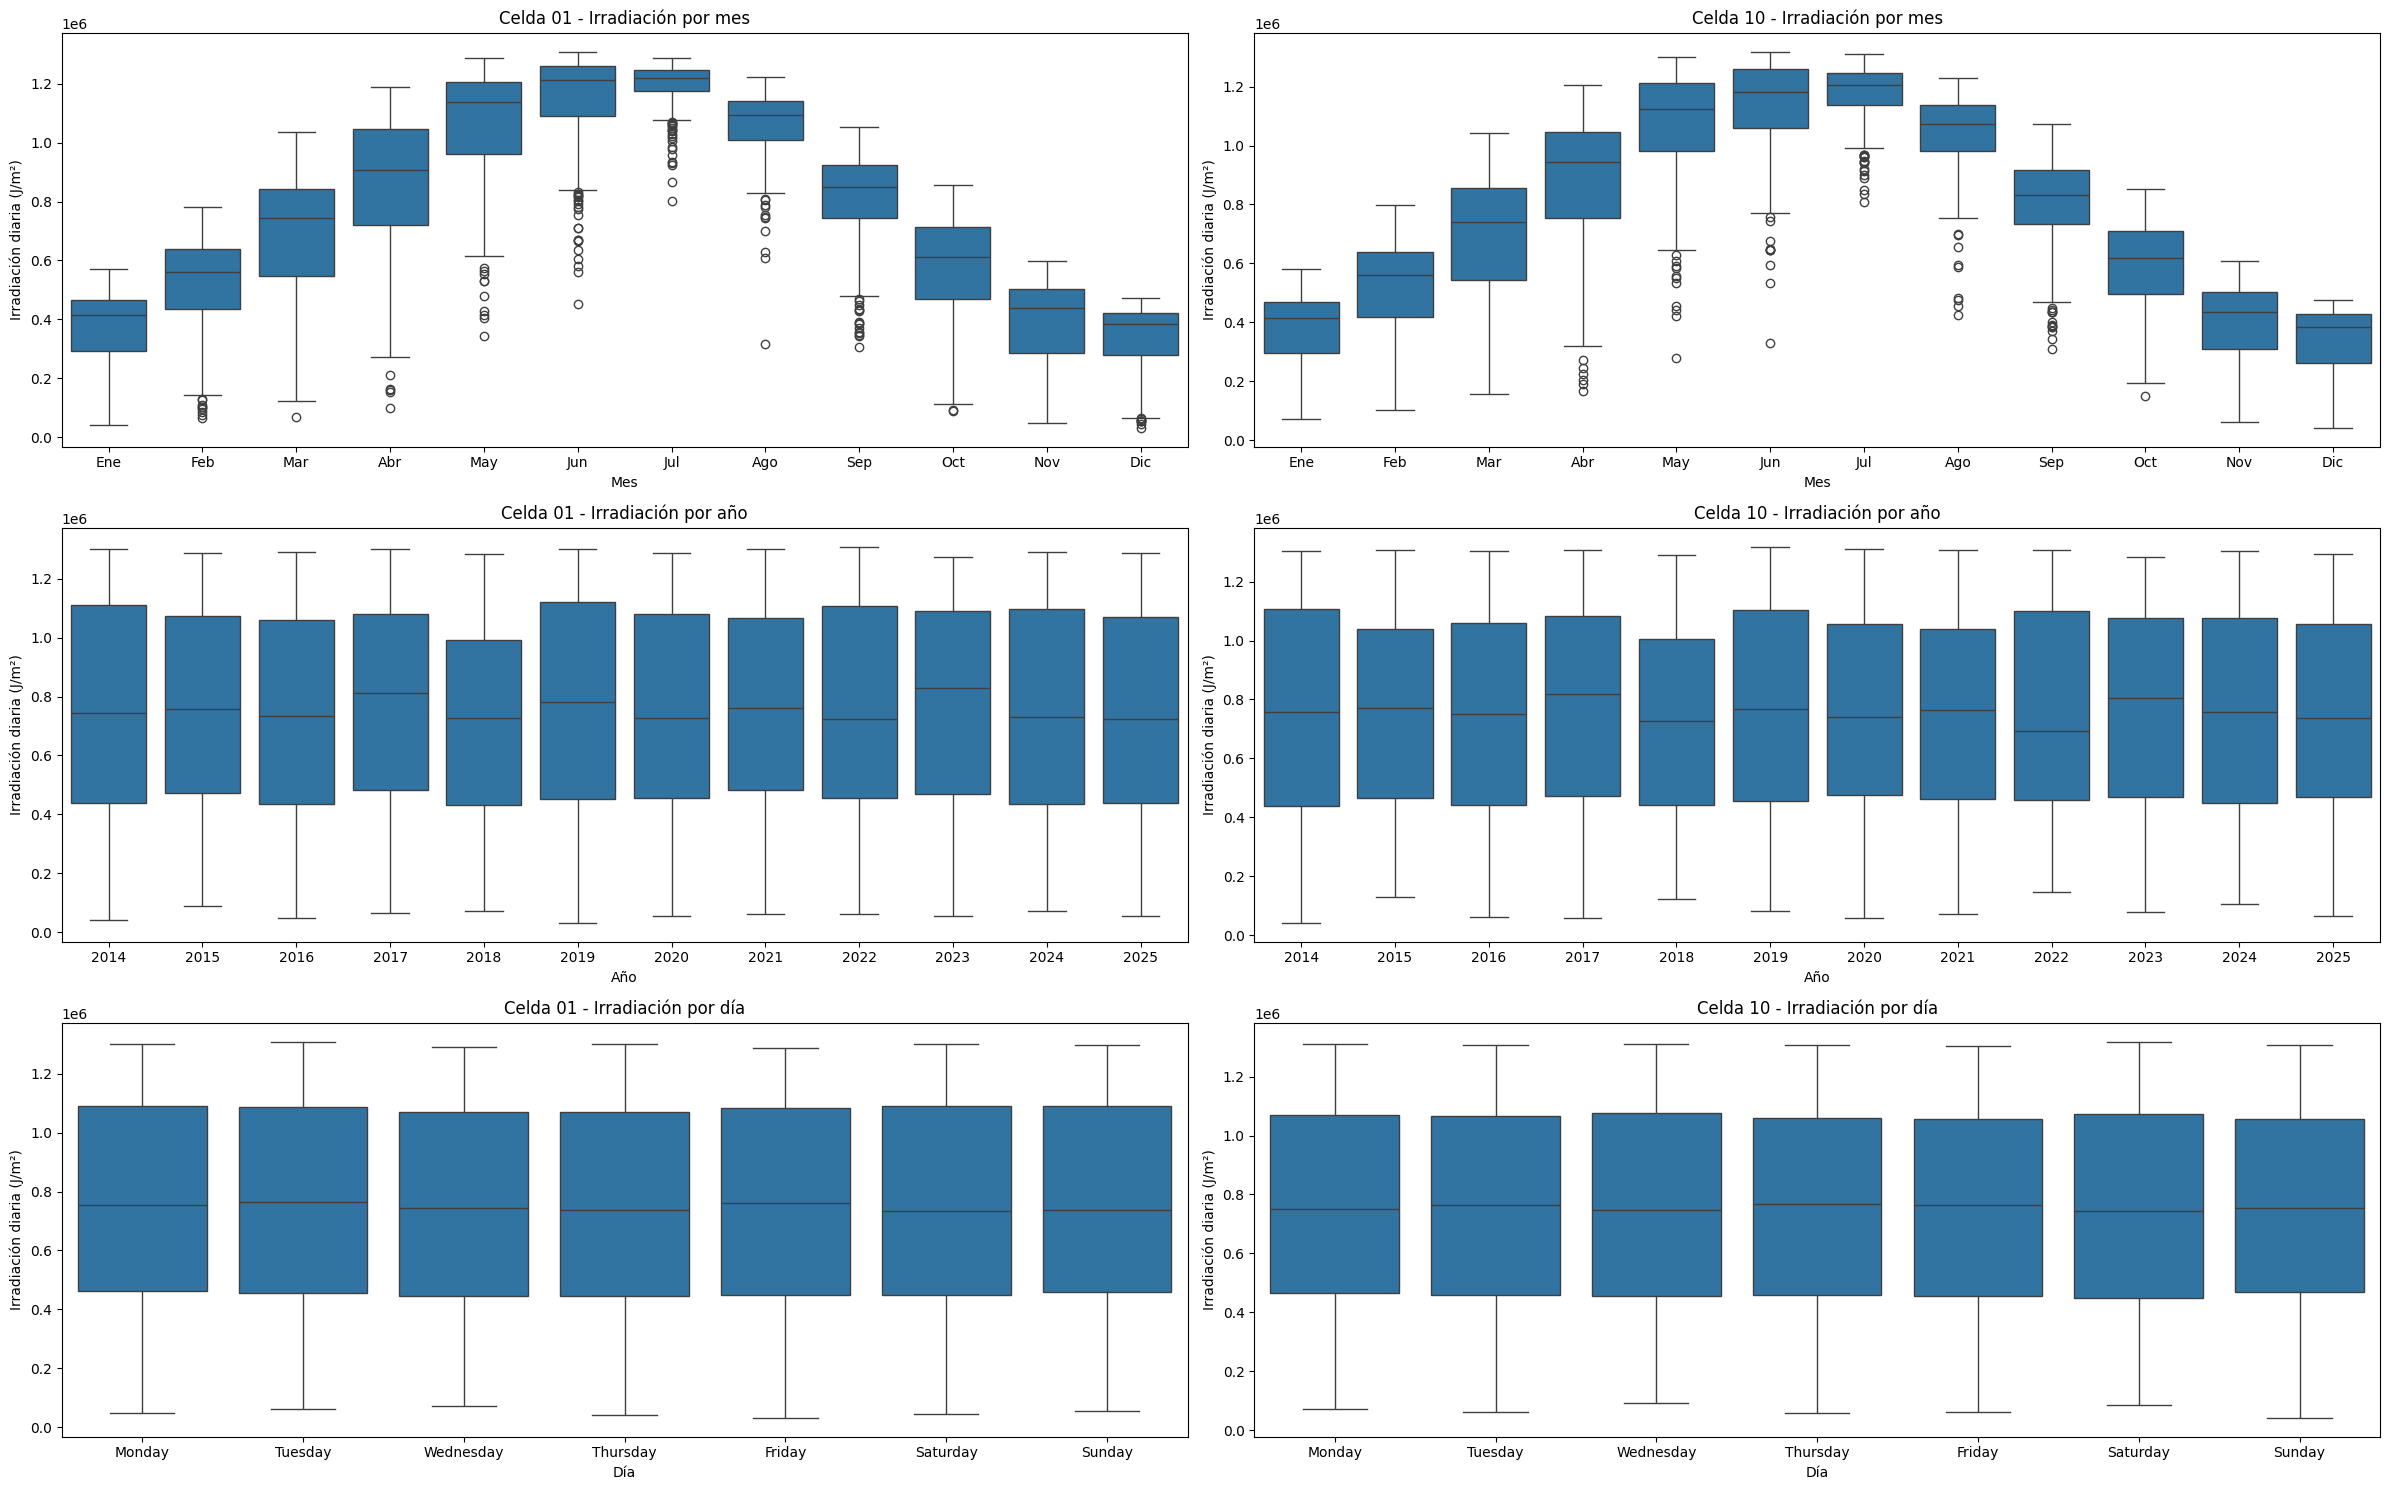


Podemos ver que la irradiación se asemeja mucho a la temperatura. Cambia significativamente con el mes (lógicamente), y no cambia nada con el día de la semana.
También vemos que con el año cambia ligeramente, aunque se mantiene muy estable (más incluso que la temperatura).


In [11]:
MESES = {1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun',
         7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(24, 15))

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# COLUMNA DE LA IZQUIERDA: CELDA 01

# 1. Distribucion por mes
sns.boxplot(x='MES', y='IRRAD_CELDA01', data=df_orig_irrad, ax=axes[0, 0])
axes[0, 0].set_title('Celda 01 - Irradiación por mes')
axes[0, 0].set_xlabel('Mes')
axes[0, 0].set_ylabel('Irradiación diaria (J/m²)')
axes[0, 0].set_xticklabels([MESES[i] for i in range(1, 13)])

# 2. Distribucion por año
sns.boxplot(x='ANNO', y='IRRAD_CELDA01', data=df_orig_irrad, ax=axes[1, 0])
axes[1, 0].set_title('Celda 01 - Irradiación por año')
axes[1, 0].set_xlabel('Año')
axes[1, 0].set_ylabel('Irradiación diaria (J/m²)')

# 3. Distribucion por dia de la semana
sns.boxplot(x='DIA', y='IRRAD_CELDA01', data=df_orig_irrad, order=days_order, ax=axes[2, 0])
axes[2, 0].set_title('Celda 01 - Irradiación por día')
axes[2, 0].set_xlabel('Día')
axes[2, 0].set_ylabel('Irradiación diaria (J/m²)')

# COLUMNA DE LA DERECHA: CELDA 10

# 1. Distribucion por mes
sns.boxplot(x='MES', y='IRRAD_CELDA10', data=df_orig_irrad, ax=axes[0, 1])
axes[0, 1].set_title('Celda 10 - Irradiación por mes')
axes[0, 1].set_xlabel('Mes')
axes[0, 1].set_ylabel('Irradiación diaria (J/m²)')
axes[0, 1].set_xticklabels([MESES[i] for i in range(1, 13)])

# 2. Distribucion por año
sns.boxplot(x='ANNO', y='IRRAD_CELDA10', data=df_orig_irrad, ax=axes[1, 1])
axes[1, 1].set_title('Celda 10 - Irradiación por año')
axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('Irradiación diaria (J/m²)')

# 3. Distribucion por dia de la semana
sns.boxplot(x='DIA', y='IRRAD_CELDA10', data=df_orig_irrad, order=days_order, ax=axes[2, 1])
axes[2, 1].set_title('Celda 10 - Irradiación por día')
axes[2, 1].set_xlabel('Día')
axes[2, 1].set_ylabel('Irradiación diaria (J/m²)')

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 1.9： Irradiación en las celdas 01 y 10 según el día de la semana, el mes y el año.png', dpi=300, bbox_inches='tight')
plt.show()

print("""
Podemos ver que la irradiación se asemeja mucho a la temperatura. Cambia significativamente con el mes (lógicamente), y no cambia nada con el día de la semana.
También vemos que con el año cambia ligeramente, aunque se mantiene muy estable (más incluso que la temperatura).""")


### Precipitación celdas 01 y 10

C:\Users\anton\AppData\Local\Temp\ipykernel_19716\2798952081.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels([MESES[i] for i in range(1, 13)])
C:\Users\anton\AppData\Local\Temp\ipykernel_19716\2798952081.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels([MESES[i] for i in range(1, 13)])


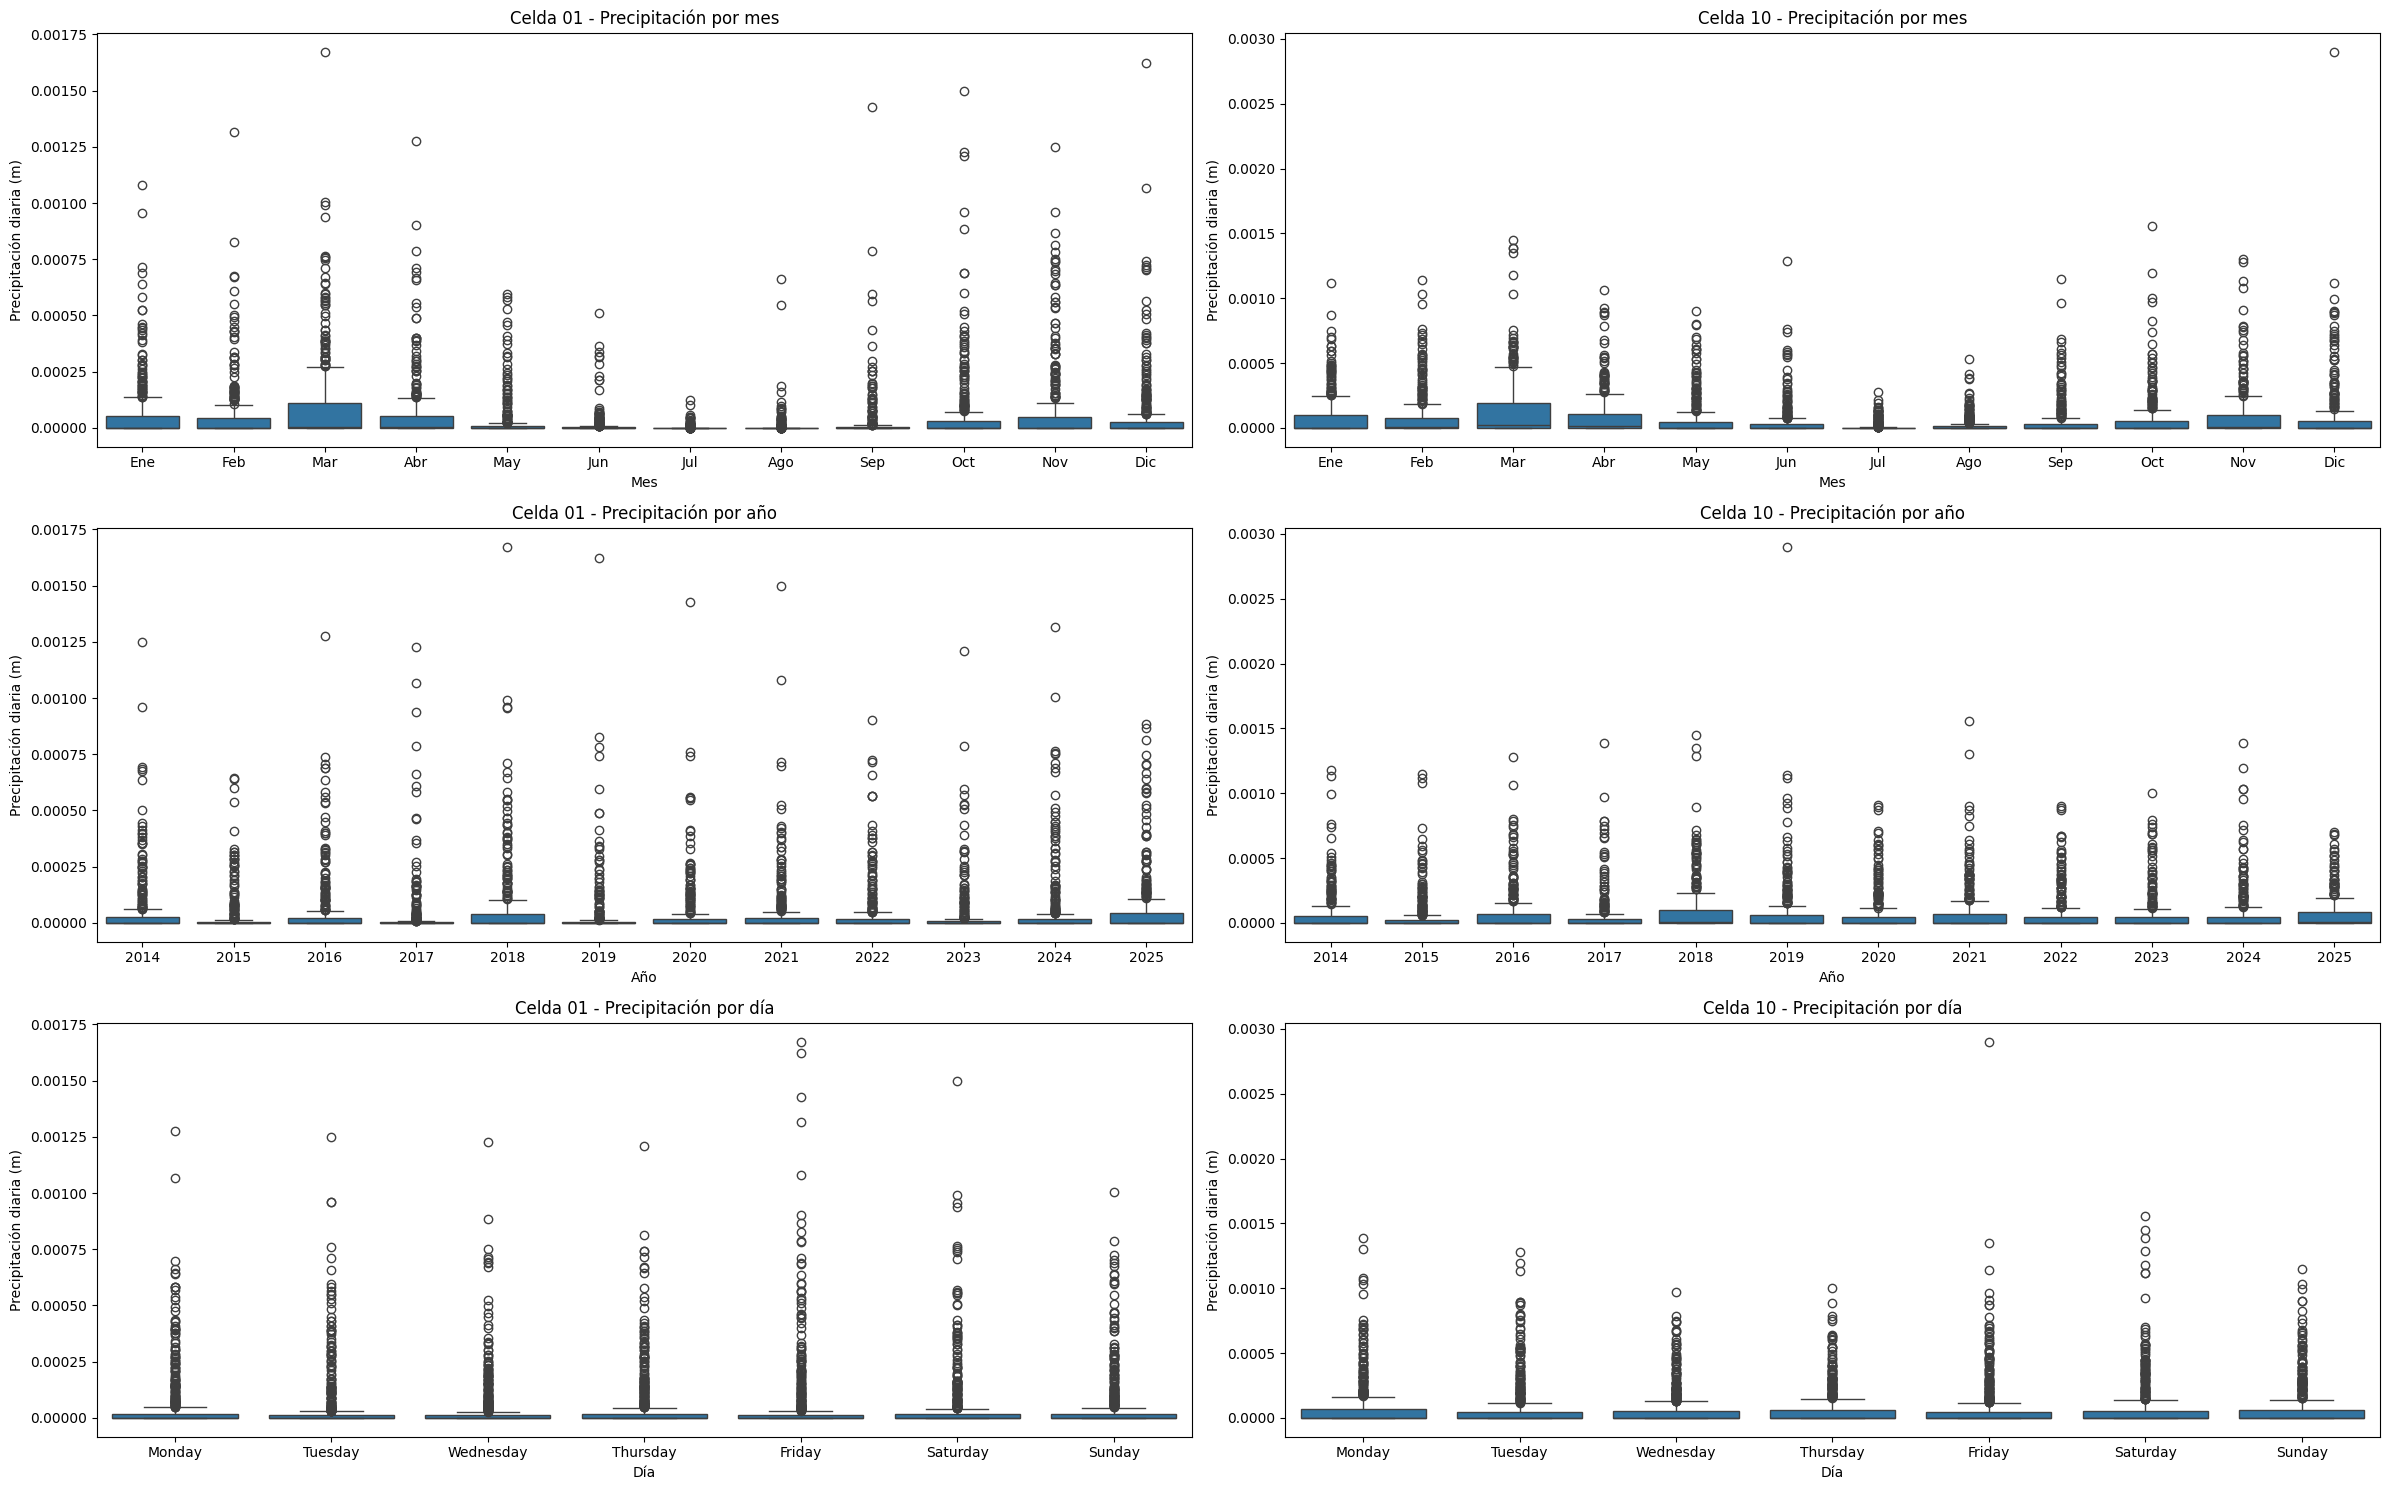


La precipitación es diferente a las otras variables. Podemos ver que en marzo es cuando más precipitación hay, y que prácticamente no hay nada durante el verano.
También cambia un poco por año, sobre todo en la celda 01 (que hemos visto que seguramente sea de una zona más al Sur).
Con el día de la semana es completamente estable, como cabría esperar.

Los datos atípicos más llamativos aparecen en las medidas mensuales, ya que (sobre todo en temperatura e irradiación) si un día cambia el tiempo las medidas bajan de manera significativa.
En temperatura:
      Vemos outliers sobre todo en los meses de transición entre invierno y verano, es decir, marzo, abril, octubre, y luego también en días de verano en los que hace menos calor (seguramente debido a lluvia).
En irradiación:
      Los outliers siempre están hacia abajo, es decir, que hay mucha menos irradiación de la que cabría esperar. Esto seguramente sea debido a que esos días está nublado, o llueve.
En precipitación:
      Hay muchí

In [12]:
MESES = {1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun',
         7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(24, 15))

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# COLUMNA DE LA IZQUIERDA: CELDA 01

# 1. Distribucion por mes
sns.boxplot(x='MES', y='PRECIP_CELDA01', data=df_orig_precip, ax=axes[0, 0])
axes[0, 0].set_title('Celda 01 - Precipitación por mes')
axes[0, 0].set_xlabel('Mes')
axes[0, 0].set_ylabel('Precipitación diaria (m)')
axes[0, 0].set_xticklabels([MESES[i] for i in range(1, 13)])

# 2. Distribucion por año
sns.boxplot(x='ANNO', y='PRECIP_CELDA01', data=df_orig_precip, ax=axes[1, 0])
axes[1, 0].set_title('Celda 01 - Precipitación por año')
axes[1, 0].set_xlabel('Año')
axes[1, 0].set_ylabel('Precipitación diaria (m)')

# 3. Distribucion por dia de la semana
sns.boxplot(x='DIA', y='PRECIP_CELDA01', data=df_orig_precip, order=days_order, ax=axes[2, 0])
axes[2, 0].set_title('Celda 01 - Precipitación por día')
axes[2, 0].set_xlabel('Día')
axes[2, 0].set_ylabel('Precipitación diaria (m)')

# COLUMNA DE LA DERECHA: CELDA 10

# 1. Distribucion por mes
sns.boxplot(x='MES', y='PRECIP_CELDA10', data=df_orig_precip, ax=axes[0, 1])
axes[0, 1].set_title('Celda 10 - Precipitación por mes')
axes[0, 1].set_xlabel('Mes')
axes[0, 1].set_ylabel('Precipitación diaria (m)')
axes[0, 1].set_xticklabels([MESES[i] for i in range(1, 13)])

# 2. Distribucion por año
sns.boxplot(x='ANNO', y='PRECIP_CELDA10', data=df_orig_precip, ax=axes[1, 1])
axes[1, 1].set_title('Celda 10 - Precipitación por año')
axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('Precipitación diaria (m)')

# 3. Distribucion por dia de la semana
sns.boxplot(x='DIA', y='PRECIP_CELDA10', data=df_orig_precip, order=days_order, ax=axes[2, 1])
axes[2, 1].set_title('Celda 10 - Precipitación por día')
axes[2, 1].set_xlabel('Día')
axes[2, 1].set_ylabel('Precipitación diaria (m)')

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 1.10： Precipitación en las celdas 01 y 10 según el día de la semana, el mes y el año.png', dpi=300, bbox_inches='tight')
plt.show()

print("""
La precipitación es diferente a las otras variables. Podemos ver que en marzo es cuando más precipitación hay, y que prácticamente no hay nada durante el verano.
También cambia un poco por año, sobre todo en la celda 01 (que hemos visto que seguramente sea de una zona más al Sur).
Con el día de la semana es completamente estable, como cabría esperar.""")

print("""
Los datos atípicos más llamativos aparecen en las medidas mensuales, ya que (sobre todo en temperatura e irradiación) si un día cambia el tiempo las medidas bajan de manera significativa.
En temperatura:
      Vemos outliers sobre todo en los meses de transición entre invierno y verano, es decir, marzo, abril, octubre, y luego también en días de verano en los que hace menos calor (seguramente debido a lluvia).
En irradiación:
      Los outliers siempre están hacia abajo, es decir, que hay mucha menos irradiación de la que cabría esperar. Esto seguramente sea debido a que esos días está nublado, o llueve.
En precipitación:
      Hay muchísimos outliers, ya que la gran mayoría de las medidas son 0 (sin lluvia/nieve). Suele haber outliers más extremos en los meses donde más llueve, específicamente marzo y octubre.
      También podemos observar que un viernes de diciembre de 2019 llovió muchísimo, y queda como outlier casi el doble por encima de todos los demás.
""")


## 1.3. ¿Qué variable meteorológica cambia más con el mes? ¿Y con el año? (Pista: usar el coeficiente de variación).

### Variación en el mes

In [13]:
print(f"En primer lugar, debemos agrupar por mes y calcular medias mensuales.")

# TEMPERATURA
temp_medias_mes_01 = df_orig_temp.groupby('MES')['TEMP_CELDA01'].mean()
temp_medias_mes_10 = df_orig_temp.groupby('MES')['TEMP_CELDA10'].mean()

# IRRADIACIÓN
irrad_medias_mes_01 = df_orig_irrad.groupby('MES')['IRRAD_CELDA01'].mean()
irrad_medias_mes_10 = df_orig_irrad.groupby('MES')['IRRAD_CELDA10'].mean()

# PRECIPITACIÓN
precip_medias_mes_01 = df_orig_precip.groupby('MES')['PRECIP_CELDA01'].mean()
precip_medias_mes_10 = df_orig_precip.groupby('MES')['PRECIP_CELDA10'].mean()

# Mostrar las medias mensuales
print("Medias mensuales de Temperatura (Celda 01):")
print(temp_medias_mes_01)

print("\nMedias mensuales de Irradiación (Celda 01):")
print(irrad_medias_mes_01)
print("\nMedias mensuales de Precipitación (Celda 01):")
print(precip_medias_mes_01)


En primer lugar, debemos agrupar por mes y calcular medias mensuales.
Medias mensuales de Temperatura (Celda 01):
MES
1      8.518566
2     10.699247
3     12.878962
4     16.329027
5     21.281944
6     26.079428
7     30.063845
8     29.796831
9     24.514967
10    19.954943
11    13.008487
12     9.820231
Name: TEMP_CELDA01, dtype: float64

Medias mensuales de Irradiación (Celda 01):
MES
1     3.717112e+05
2     5.215731e+05
3     6.859988e+05
4     8.590105e+05
5     1.064870e+06
6     1.152043e+06
7     1.201056e+06
8     1.066921e+06
9     8.161618e+05
10    5.791952e+05
11    3.959181e+05
12    3.387523e+05
Name: IRRAD_CELDA01, dtype: float64

Medias mensuales de Precipitación (Celda 01):
MES
1     0.000059
2     0.000057
3     0.000099
4     0.000062
5     0.000030
6     0.000014
7     0.000003
8     0.000008
9     0.000028
10    0.000061
11    0.000080
12    0.000057
Name: PRECIP_CELDA01, dtype: float64


In [14]:
print(f"Para interpretar mejor las medias agrupadas por mes, representamos los datos en histogramas comparativos:")

Para interpretar mejor las medias agrupadas por mes, representamos los datos en histogramas comparativos:


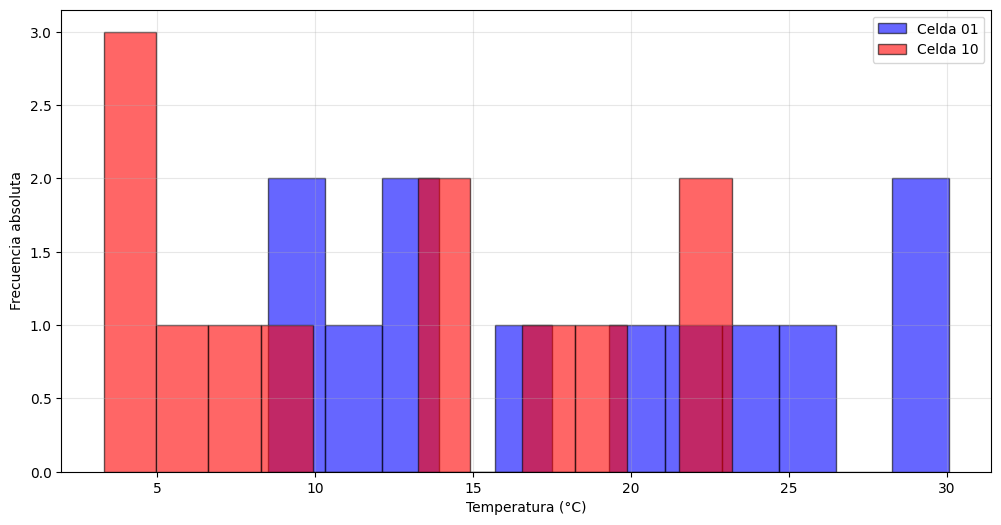

In [15]:
# Histograma comparativo de Temperatura (Celda 01 y 10)
fig = plt.figure(figsize=(12, 6))

plt.hist(temp_medias_mes_01, bins=12, alpha=0.6, label='Celda 01', color='blue', edgecolor='black')
plt.hist(temp_medias_mes_10, bins=12, alpha=0.6, label='Celda 10', color='red', edgecolor='black')

plt.xlabel('Temperatura (°C)')
plt.ylabel('Frecuencia absoluta')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(IMAGES_DIR / 'Gráfico 1.11： Distribución de las temperaturas medias mensuales en las Celdas 01 y 10.png', dpi=300, bbox_inches='tight')
plt.show()

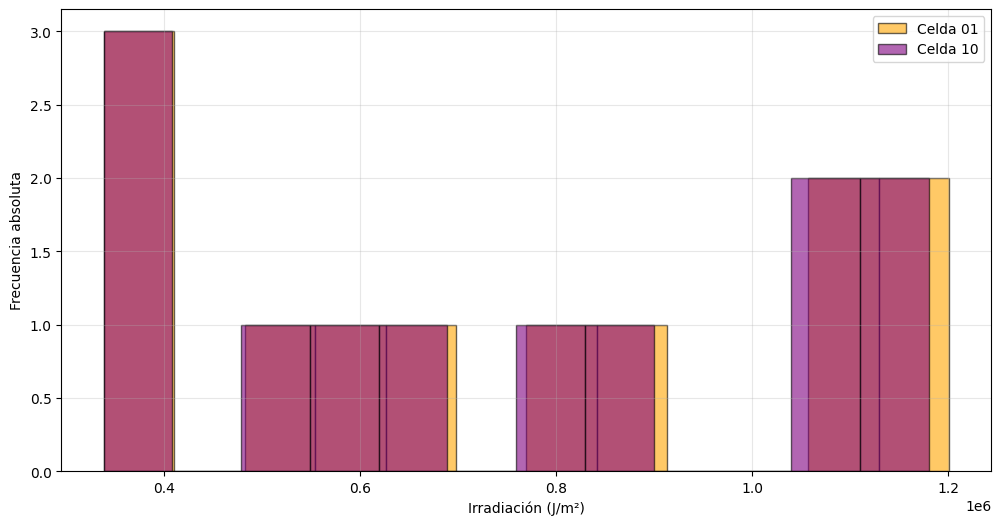

In [16]:
# Histograma comparativo de Irradiación (Celda 01 y 10)
fig = plt.figure(figsize=(12, 6))

plt.hist(irrad_medias_mes_01, bins=12, alpha=0.6, label='Celda 01', color='orange', edgecolor='black')
plt.hist(irrad_medias_mes_10, bins=12, alpha=0.6, label='Celda 10', color='purple', edgecolor='black')

plt.xlabel('Irradiación (J/m²)')
plt.ylabel('Frecuencia absoluta')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(IMAGES_DIR / 'Gráfico 1.12： Distribución de las irradiaciones medias mensuales en las Celdas 01 y 10.png', dpi=300, bbox_inches='tight')
plt.show()

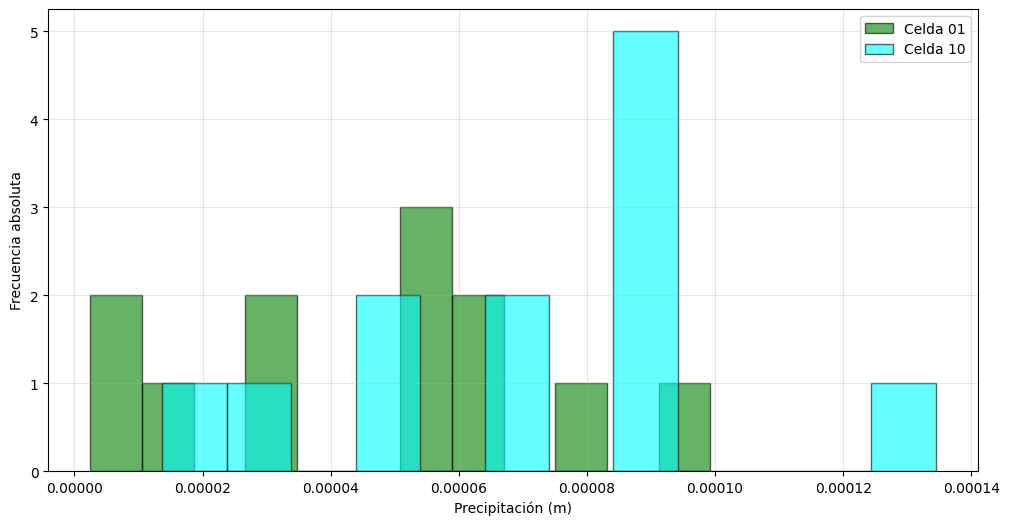

In [17]:
# Histograma comparativo de Precipitación (Celda 01 y 10)
fig = plt.figure(figsize=(12, 6))

plt.hist(precip_medias_mes_01, bins=12, alpha=0.6, label='Celda 01', color='green', edgecolor='black')
plt.hist(precip_medias_mes_10, bins=12, alpha=0.6, label='Celda 10', color='cyan', edgecolor='black')

plt.xlabel('Precipitación (m)')
plt.ylabel('Frecuencia absoluta')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(IMAGES_DIR / 'Gráfico 1.13： Distribución de las precipitaciones medias mensuales en las Celdas 01 y 10.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
print(f"En segundo lugar, debemos calcular el coeficiente de variación (CV = desviación estándar / media x 100).")

def coeficiente_variacion(datos):
    return (datos.std() / datos.mean()) * 100

cv_temp_mes_01 = coeficiente_variacion(temp_medias_mes_01)
cv_irrad_mes_01 = coeficiente_variacion(irrad_medias_mes_01)
cv_precip_mes_01 = coeficiente_variacion(precip_medias_mes_01)

print("\n--- Coeficientes de variación por mes (celda 01) ---")
print(f"Temperatura: {cv_temp_mes_01:.2f}%")
print(f"Irradiación: {cv_irrad_mes_01:.2f}%")
print(f"Precipitación: {cv_precip_mes_01:.2f}%")

cv_temp_mes_10 = coeficiente_variacion(temp_medias_mes_10)
cv_irrad_mes_10 = coeficiente_variacion(irrad_medias_mes_10)
cv_precip_mes_10 = coeficiente_variacion(precip_medias_mes_10)

print("\n--- Coeficientes de variación por mes (celda 10) ---")
print(f"Temperatura: {cv_temp_mes_10:.2f}%")
print(f"Irradiación: {cv_irrad_mes_10:.2f}%")
print(f"Precipitación: {cv_precip_mes_10:.2f}%")


En segundo lugar, debemos calcular el coeficiente de variación (CV = desviación estándar / media x 100).

--- Coeficientes de variación por mes (celda 01) ---
Temperatura: 41.91%
Irradiación: 41.99%
Precipitación: 64.20%

--- Coeficientes de variación por mes (celda 10) ---
Temperatura: 59.77%
Irradiación: 40.94%
Precipitación: 46.91%


In [19]:
cv_mes_01 = {
    'temperatura': cv_temp_mes_01,
    'irradiación': cv_irrad_mes_01,
    'precipitación': cv_precip_mes_01
}
variable_mes_01 = max(cv_mes_01, key=cv_mes_01.get)

print("Para la celda 01:")
print(f"La variable meteorológica que más cambia con el mes es {variable_mes_01}, con un coeficiente de variación de {cv_mes_01[variable_mes_01]:.2f}%.")

Para la celda 01:
La variable meteorológica que más cambia con el mes es precipitación, con un coeficiente de variación de 64.20%.


In [20]:
cv_mes_10 = {
    'temperatura': cv_temp_mes_10,
    'irradiación': cv_irrad_mes_10,
    'precipitación': cv_precip_mes_10
}
variable_mes_10 = max(cv_mes_10, key=cv_mes_10.get)

print("Para la celda 10:")
print(f"La variable meteorológica que más cambia con el mes es {variable_mes_10}, con un coeficiente de variación de {cv_mes_10[variable_mes_10]:.2f}%.")

Para la celda 10:
La variable meteorológica que más cambia con el mes es temperatura, con un coeficiente de variación de 59.77%.


### Variación en el año

In [21]:
print("En primer lugar, debemos agrupar por año y calcular medias anuales.")

# TEMPERATURA
temp_medias_anual_01 = df_orig_temp.groupby('ANNO')['TEMP_CELDA01'].mean()
temp_medias_anual_10 = df_orig_temp.groupby('ANNO')['TEMP_CELDA10'].mean()

# IRRADIACIÓN
irrad_medias_anual_01 = df_orig_irrad.groupby('ANNO')['IRRAD_CELDA01'].mean()
irrad_medias_anual_10 = df_orig_irrad.groupby('ANNO')['IRRAD_CELDA10'].mean()

# PRECIPITACIÓN
precip_medias_anual_01 = df_orig_precip.groupby('ANNO')['PRECIP_CELDA01'].mean()
precip_medias_anual_10 = df_orig_precip.groupby('ANNO')['PRECIP_CELDA10'].mean()

# Mostrar las medias anuales
print("Medias anuales de Temperatura (Celda 01):")
print(temp_medias_anual_01)

print("\nMedias anuales de Irradiación (Celda 01):")
print(irrad_medias_anual_01)
print("\nMedias anuales de Precipitación (Celda 01):")
print(precip_medias_anual_01)


En primer lugar, debemos agrupar por año y calcular medias anuales.
Medias anuales de Temperatura (Celda 01):
ANNO
2014    17.871983
2015    18.605577
2016    18.393011
2017    19.093971
2018    17.386818
2019    18.431537
2020    18.594371
2021    18.330461
2022    19.421633
2023    19.366072
2024    18.965782
2025    19.012425
Name: TEMP_CELDA01, dtype: float64

Medias anuales de Irradiación (Celda 01):
ANNO
2014    748720.520038
2015    771193.198647
2016    744571.007117
2017    779435.124967
2018    725502.800466
2019    769557.413710
2020    742130.986344
2021    760602.245214
2022    762083.175836
2023    776445.157970
2024    749441.511806
2025    737903.320849
Name: IRRAD_CELDA01, dtype: float64

Medias anuales de Precipitación (Celda 01):
ANNO
2014    0.000050
2015    0.000031
2016    0.000052
2017    0.000034
2018    0.000068
2019    0.000037
2020    0.000044
2021    0.000045
2022    0.000043
2023    0.000035
2024    0.000056
2025    0.000064
Name: PRECIP_CELDA01, dtype: flo

In [22]:
print(f"Para interpretar mejor las medias agrupadas por año, representamos los datos en histogramas comparativos:")

Para interpretar mejor las medias agrupadas por año, representamos los datos en histogramas comparativos:


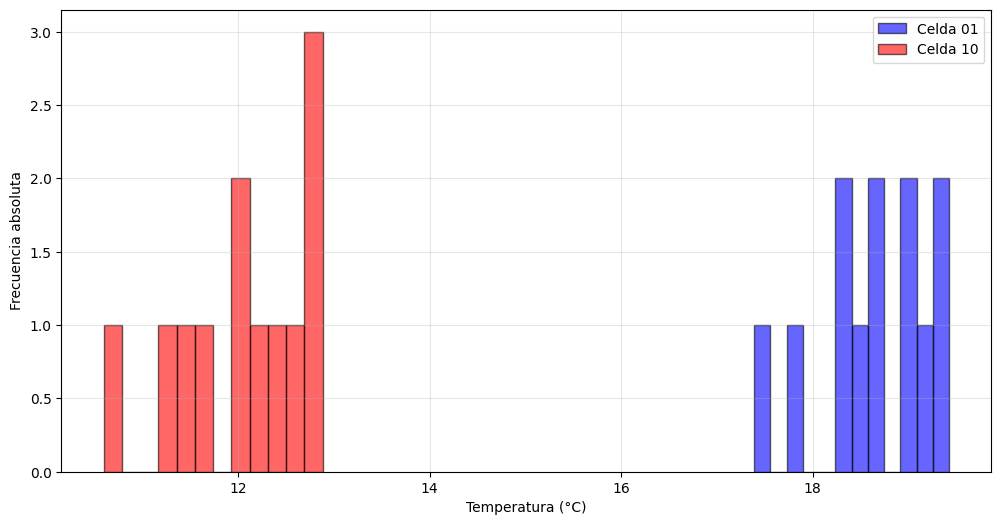

In [23]:
# Histograma comparativo de Temperatura (Celda 01 y 10)
fig = plt.figure(figsize=(12, 6))

plt.hist(temp_medias_anual_01, bins=12, alpha=0.6, label='Celda 01', color='blue', edgecolor='black')
plt.hist(temp_medias_anual_10, bins=12, alpha=0.6, label='Celda 10', color='red', edgecolor='black')

plt.xlabel('Temperatura (°C)')
plt.ylabel('Frecuencia absoluta')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(IMAGES_DIR / 'Gráfico 1.14： Distribución de las temperaturas medias anuales en las Celdas 01 y 10.png', dpi=300, bbox_inches='tight')
plt.show()

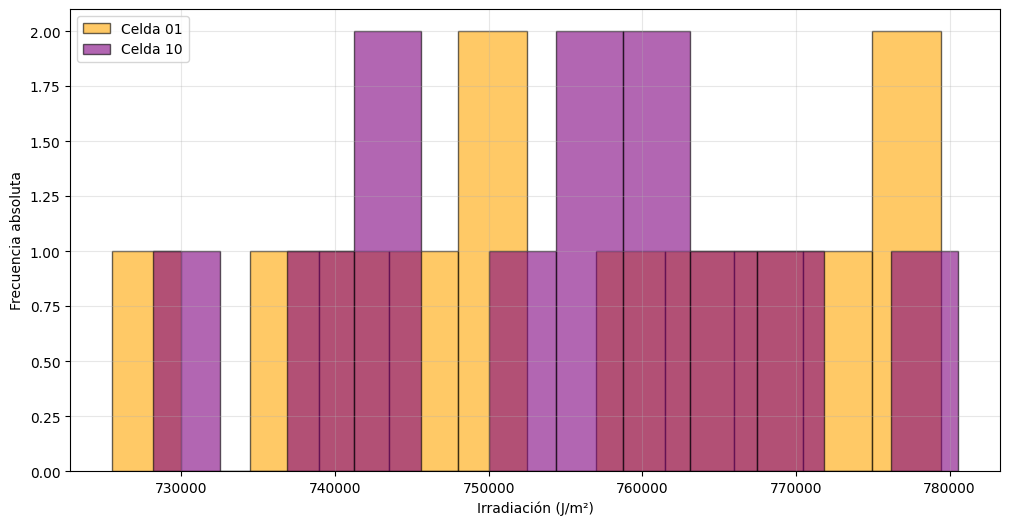

In [24]:
# Histograma comparativo de Irradiación (Celda 01 y 10)
fig = plt.figure(figsize=(12, 6))

plt.hist(irrad_medias_anual_01, bins=12, alpha=0.6, label='Celda 01', color='orange', edgecolor='black')
plt.hist(irrad_medias_anual_10, bins=12, alpha=0.6, label='Celda 10', color='purple', edgecolor='black')

plt.xlabel('Irradiación (J/m²)')
plt.ylabel('Frecuencia absoluta')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(IMAGES_DIR / 'Gráfico 1.15： Distribución de las irradiaciones medias anuales en las Celdas 01 y 10.png', dpi=300, bbox_inches='tight')
plt.show()

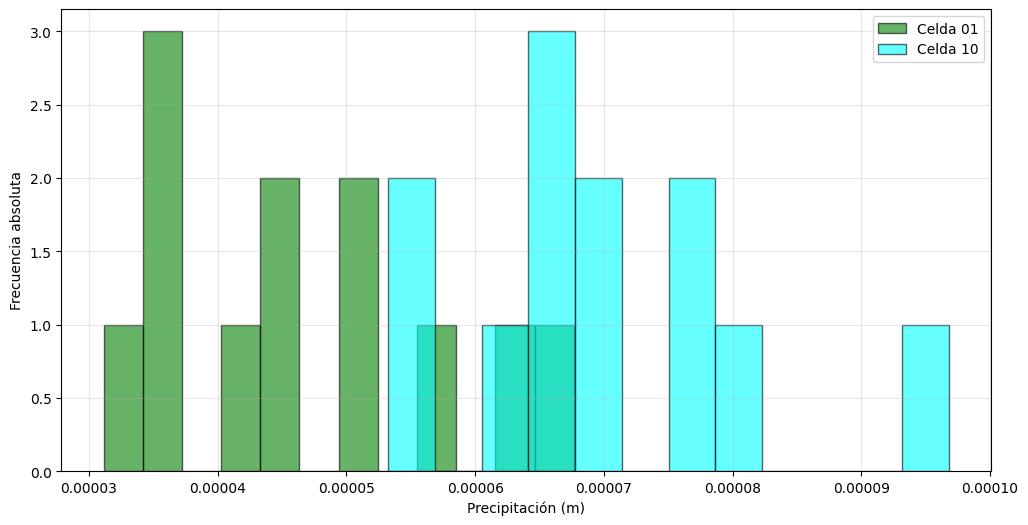

In [25]:
# Histograma comparativo de Precipitación (Celda 01 y 10)
fig = plt.figure(figsize=(12, 6))

plt.hist(precip_medias_anual_01, bins=12, alpha=0.6, label='Celda 01', color='green', edgecolor='black')
plt.hist(precip_medias_anual_10, bins=12, alpha=0.6, label='Celda 10', color='cyan', edgecolor='black')

plt.xlabel('Precipitación (m)')
plt.ylabel('Frecuencia absoluta')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(IMAGES_DIR / 'Gráfico 1.16： Distribución de las precipitaciones medias anuales en las Celdas 01 y 10.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
print(f"En segundo lugar, debemos calcular el coeficiente de variación (CV = desviación estándar / media x 100).")

def coeficiente_variacion(datos):
    return (datos.std() / datos.mean()) * 100

cv_temp_anual_01 = coeficiente_variacion(temp_medias_anual_01)
cv_irrad_anual_01 = coeficiente_variacion(irrad_medias_anual_01)
cv_precip_anual_01 = coeficiente_variacion(precip_medias_anual_01)

print("\n--- Coeficientes de variación por año (celda 01) ---")
print(f"Temperatura: {cv_temp_anual_01:.2f}%")
print(f"Irradiación: {cv_irrad_anual_01:.2f}%")
print(f"Precipitación: {cv_precip_anual_01:.2f}%")

cv_temp_anual_10 = coeficiente_variacion(temp_medias_anual_10)
cv_irrad_anual_10 = coeficiente_variacion(irrad_medias_anual_10)
cv_precip_anual_10 = coeficiente_variacion(precip_medias_anual_10)

print("\n--- Coeficientes de variación por año (celda 10) ---")
print(f"Temperatura: {cv_temp_anual_10:.2f}%")
print(f"Irradiación: {cv_irrad_anual_10:.2f}%")
print(f"Precipitación: {cv_precip_anual_10:.2f}%")


En segundo lugar, debemos calcular el coeficiente de variación (CV = desviación estándar / media x 100).

--- Coeficientes de variación por año (celda 01) ---
Temperatura: 3.22%
Irradiación: 2.23%
Precipitación: 25.14%

--- Coeficientes de variación por año (celda 10) ---
Temperatura: 5.98%
Irradiación: 1.87%
Precipitación: 16.58%


In [27]:
cv_anual_01 = {
    'temperatura': cv_temp_anual_01,
    'irradiación': cv_irrad_anual_01,
    'precipitación': cv_precip_anual_01
}
variable_anual_01 = max(cv_anual_01, key=cv_anual_01.get)

print("Para la celda 01:")
print(f"La variable meteorológica que más cambia con el año es {variable_anual_01}, con un coeficiente de variación de {cv_anual_01[variable_anual_01]:.2f}%.")

Para la celda 01:
La variable meteorológica que más cambia con el año es precipitación, con un coeficiente de variación de 25.14%.


In [28]:
cv_anual_10 = {
    'temperatura': cv_temp_anual_10,
    'irradiación': cv_irrad_anual_10,
    'precipitación': cv_precip_anual_10
}
variable_anual_10 = max(cv_anual_10, key=cv_anual_10.get)

print("Para la celda 10:")
print(f"La variable meteorológica que más cambia con el año es {variable_anual_10}, con un coeficiente de variación de {cv_anual_10[variable_anual_10]:.2f}%.")

Para la celda 10:
La variable meteorológica que más cambia con el año es precipitación, con un coeficiente de variación de 16.58%.
